<h1 style="color:#b10043"> <strong> Modelisation de signaux aléatoires - Projet </strong> </h1>  

<small>     
Marco Guzzo, <br> 
Laura Luzzi, <br>  
Mathieu Guerquin-Kern, <br> 
Inbar Fijalkow <br>

vers. 2025 </small>

**Binôme :**

- Etudiant 1   POLONOWSKI
- Etudiant 2  FADE

***  
## Sommaire
- [Contexte](#contexte)
    - [Un modèle source/filtre pour la voix](#c-modele)
    - [Une stationnarité limitée dans le temps](#c-stat)
    - [Schéma d'analyse et de synthèse à suivre](#c-schema)
- [Séance 1 : Estimation de l'autocorrélation](#seance1)
    - [Des données sur lesquelles travailler](#s1-gen-sig)
    - [Estimateur biaisé de l'autocorrélation](#s1-autocorr-b)
    - [Estimateur non-biaisé de l'autocorrélation](#s1-autocorr-nb)
    - [Etablissement d'un critère pour le caractère voisé](#s1-voise)
    - [Pour aller plus loin](#s1-further)
- [Séance 2 : Analyse spectrale](#seance2)
    - [Deux approches pour un même estimateur (ou presque)](#s2-estim)
    - [Fiabilité de l'estimation spectrale](#s2-wk)
    - [Choix d'une fenêtre temporelle](#s2-fenetrage)
- [Séance 3 : Prédiction linéaire](#seance3)
    - [Résolution des équations de Yule-Walker](#s3-yule-walker)
    - [Réalisations de processus connus](#s3-process)
    - [Sons voisés et non voisés](#s3-v-nv)
- [Séance 4 : Codage, décodage et effets sur la parole](#seance4)
    - [Analyse d'un tronçon](#s4-analyse)
    - [Synthèse d'un tronçon](#s4-synthese)
    - [Traitement d'un signal et effets](#s4-tns-effets)

$\quad$  
***

Les quatre séances de TP de majeure de Signal du semestre 7 (« Modélisation des Signaux Aléatoires») prennent la forme d’un projet unique réalisé dans l’environnement Jupyter Notebook. Les fichiers nécessaires sont accessibles sur Moodle.  
Vous ajouterez des cellules de type "Code" pour toute la partie programmation et de type "Markdown" pour la partie commentaire.

L'évaluation se fera sur la base du **travail réalisé en séance**. Pour cela vous préviendrez votre professeur lorsque vous atteindrez un <span style="color:blue"> **Checkpoint** </span>.  

Avant de vous lancer dans le codage, rappelez sur une feuille la formule de la fonction que vous allez programmer.

On préfèrera préciser ici en amont que toute figure se doit :
- d'avoir un titre
- d'avoir des axes labélisés
- d'avoir une légende (si plusieurs courbes)
- d'être assortie de commentaires 

In [1]:
# À lancer la première fois pour s'assurer que toutes les bibliothèques sont bien installées
!pip install -r requirements.txt


Installing packages through the IPython console doesn't work reliably in Spyder. Please use a system terminal to do that, i.e. cmd.exe on Windows, Terminal on macOS or xterm on Linux.


In [2]:
# À lancer en début de chaque relance du noyau Python

import matplotlib.pyplot as plt  # permet de faire de l'affichage
import scienceplots  # un addon du précédent pour des plus jolies figures

plt.style.use(["science", "notebook"])

import numpy as np  # pour tout ce qui est calcul vectoriel
import numpy.random as rd  # pour toute la partie aléatoire
import scipy.signal as s  # pour ce qui est filtrage
import scipy.linalg as sp
from scipy.fft import fft, fftfreq, ifft  # pour la partie fréquentielle
import soundfile as sf  # pour la gestion des fichiers audio
import librosa as lb  # certains outils de traitement du signal pour la musique
import IPython.display as ipd  # affichage inline des éléments (notamment audio ici)

***

<a id="contexte"></a>
## Contexte

> $\quad$  
> L’objectif de ce projet est de mettre en oeuvre une chaîne de codage et décodage de la voix humaine utilisant le linear predictive coding (codage par prédition linéaire). Une telle chaîne se retrouve dans des applications de transmission de la parole économes en bande passante (voir normes [GSM 06.10](https://en.wikipedia.org/wiki/Full_Rate) ou [LPC-10/FS-1015](https://en.wikipedia.org/wiki/FIPS_137)), où l’objectif est d’extraire les caractéristiques minimales du signal à transmettre (étape d’analyse du codeur) et d’être capable, à la réception, de synthétiser (codeur) un signal fidèle à l’original.  
> La maîtrise des étapes d’analyse et de synthèse ouvre également la voie à des applications créatives où un effet est appliqué à la parole en suivant trois étapes :
> - Analyse des caractéristiques de la parole.
> - Manipulation de ces caractéristiques pour obtenir un effet désiré (par exemple, changement de fréquence).
> - Synthèse de la parole à partir des caractéristiques modifiées. 
>
> On comparera les signaux réels et synthétiques avec les outils de traitement du signal (autocorrélation, spectre) et à l’oreille.  
> $\quad$

<a id="c-modele"></a>
### Un modèle source/filtre pour la voix

Des modèles plus ou moins complexes des mécanismes de production de la parole peuvent être établis.

Le plus simple d'entre eux, illustré en *Figure 1* consiste à considérer que *le signal représentant la parole est issu d'un filtre linéaire, modélisant le conduit vocal, qui est excité par une source indépendante, modélisant l'expiration passant à travers la glotte*.   
Cette source glottique peut prendre deux formes :
- **voisée** : correspondant à des vibrations vocales, modélisée par une impulsion périodique à phase aléatoire (c'est par exemple le cas pour les voyelles, ainsi que de 'b', 'd' et 'z'),
- **non voisée** : correspondant à un écoulement turbulent du flux d'air expiré, modélisé par un bruit blanc (c'est par exemple le cas pour 'p', 't', 's' et 'ch').
Cette modélisation est particulièrement utile pour élaborer des outils de compression de la parole : la parole n'est plus représentée comme une suite d'échantillons, mais directement à partir d'une suite de modèles source/filtre. 

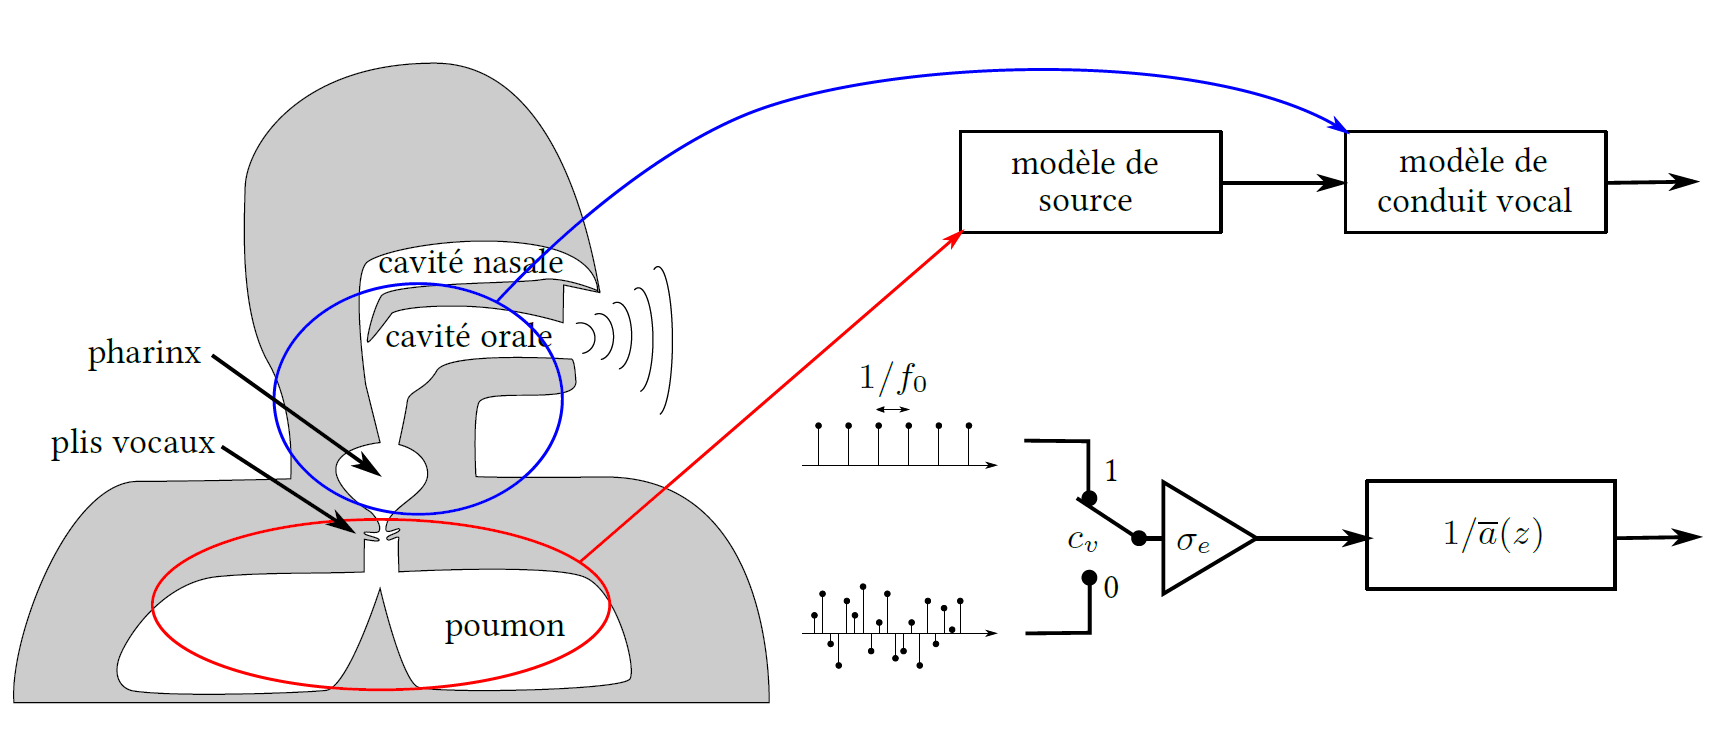

*Figure 1* - Illustration du modèle source/filtre.  

Dans ce contexte, la chaîne de traitement de la parole comprend deux étapes :
- une partie codage (analyse) dont le but est d'analyser le signal de parole pour en déduire une représentation sous forme de modèles source/filtre dont les paramètres sont transmis. Ainsi le débit d'information est réduit (compression).
- une partie décodage (synthèse) permettant de reconstruire le signal de parole à partir de la seule donnée des modèles source/filtre.  

Pour en savoir plus sur l'anatomie de l'appareil vocal et sa modélisation, on peut se rapporter respectivement aux [chapitres 1 et 2 de la thèse de Thomas Hézard (2014)](https://hal.archives-ouvertes.fr/tel-00933070/document).

<a id="c-stat"></a>
### Une stationnarité limitée dans le temps

Le modèle source/filtre est satisfaisant pour expliquer l'origine des sons constituant la parole (voir *Figure 2*). Alors, on peut établir des modèles aléatoires stationnaires aux ordres 1 et 2 selon que le son est voisé ou non. Néanmoins, au cours du temps, les caractéristiques du modèle sont amenées à évoluer, ce qui rompt la stationnarité.  
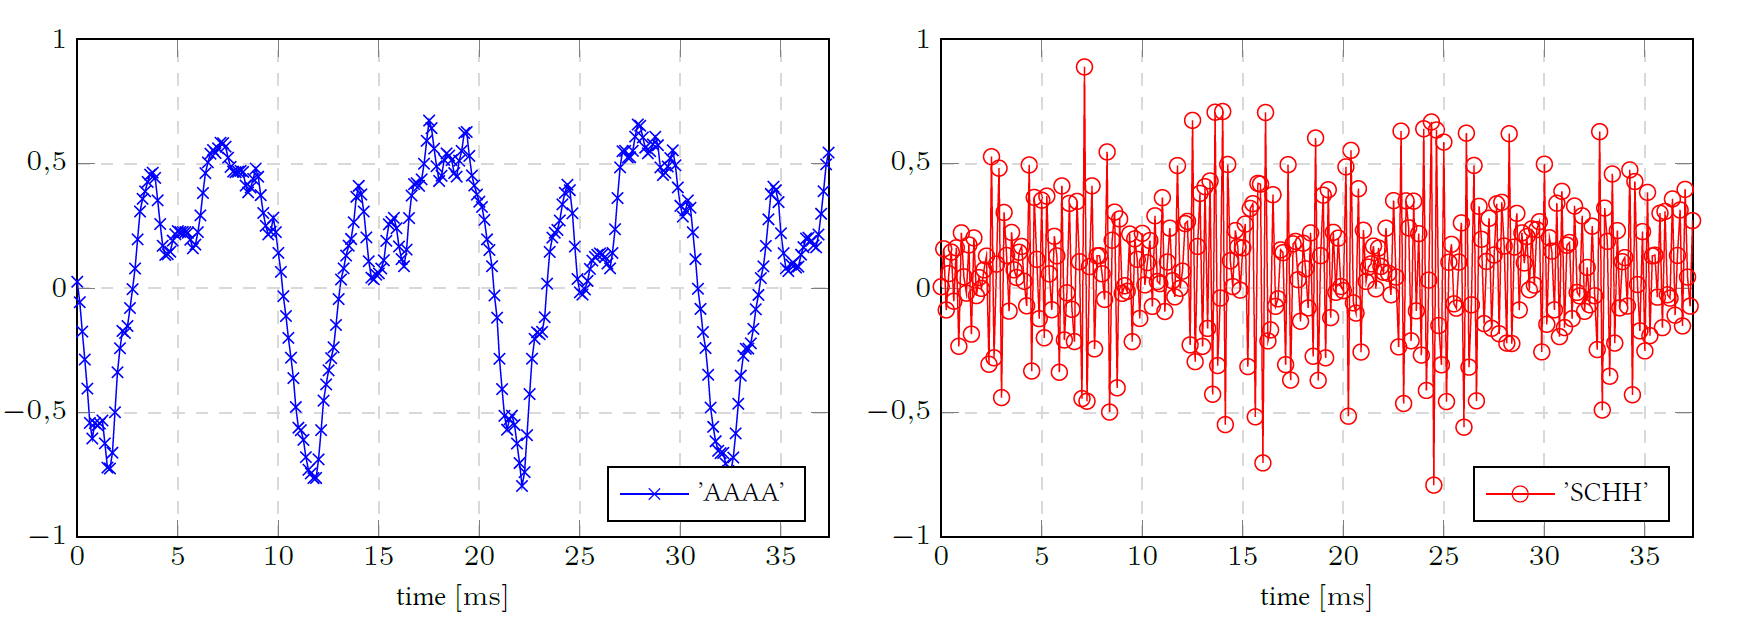

*Figure 2* - Évolutions temporelles de son voisé (à gauche) et non voisé (à droite). 

Le **son voisé** présente une pseudo-périodicité, il est très structuré. On le modélise bien avec une **impulsion périodique filtrée**. À l'inverse, le **son non voisé** est peu structuré (régulier) : il se modélise bien avec un **bruit blanc filtré**.

On considère généralement que **pour des périodes de l'ordre de 20 à 30 ms, l'hypothèse de stationnarité du signal de parole est satisfaite**.

Dans le cadre de ce projet, nous vous proposons de travailler avec une fréquence d'échantillonnage **$F_{e} = 10 \ \text{kHz}$**, suffisante pour le signal de parole, en analysant le signal par tronçons de **256 échantillons**.

<a id="c-schema"></a>
### Schéma d'analyse et de synthèse à suivre

Dans ce projet, nous vous proposons de suivre le schéma présenté en *Figure 3*. Il se décompose en deux étapes :

**L'analyse :**  
Cette première étape de la chaîne de traitement du signal de parole a pour buts :

- de découper le signal de parole en tronçons d'analyse de $N=256$ échantillons chacune,
- de déterminer, pour chaque tronçon, le filtre prédicteur optimal de $M$ paramètres $\mathbf{a}_{\text {opt }}$, le caractère voisé ou non $c_{v}$ (booléen) du tronçon et les caractéristiques du signal d'excitation : variance du signal d'excitation $\sigma_{e}^{2}$ et fréquence fondamentale $f_{0}$ (pitch) de la série d'impulsions si le son est voisé. Si le son est non voisé, le signal d'excitation, modélisé
par un bruit blanc gaussien, pourra être correctement synthétisé par la seule donnée de la variance $\sigma_{e}^{2}$.
- le codage de chaque tronçon se résume donc à $M+3$ paramètres (au lieu de $N=256$ échantillons) : les $M$ coefficients de $\mathbf{a}_{\text {opt }}, c_{v}, \sigma_{e}$ et $f_{0}$.

**La synthèse :**   
La seconde étape de la chaîne de traitement consiste à reconstituer le signal de parole tronçon par tronçon : connaissant pour chaque tronçon le type d'excitation, sa puissance, les coefficients du filtre $\operatorname{AR}(M)$, il suffit alors de générer une excitation et d'effectuer l'opération de filtrage idoine.

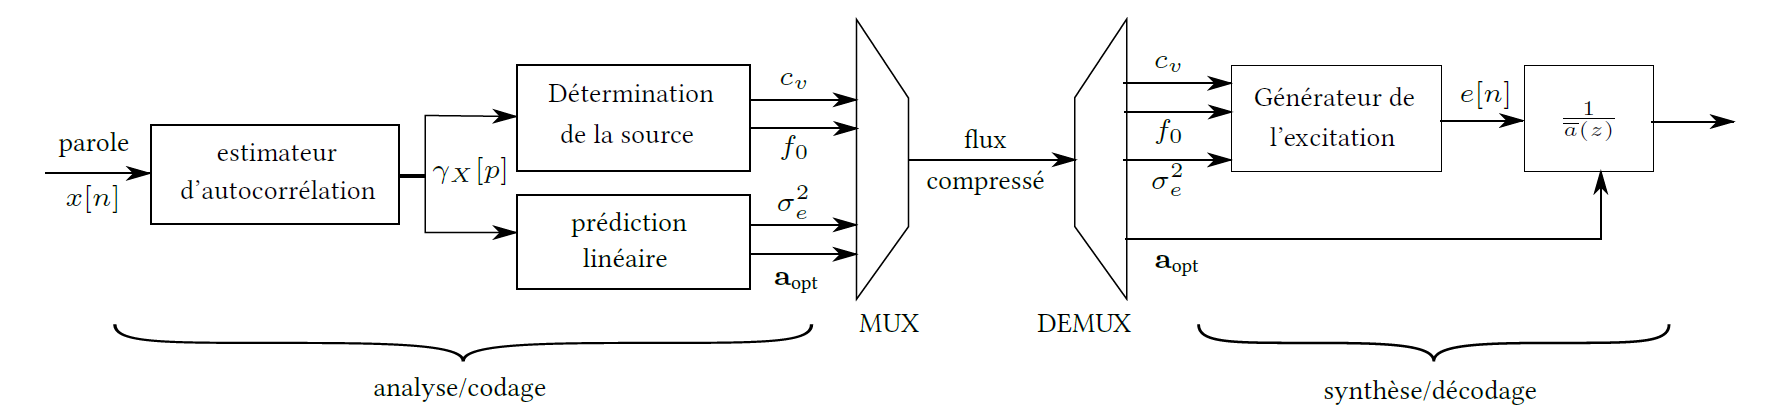  

*Figure 3* - Codage / Décodage du signal de parole.

***

<a id="seance1"></a>
## Séance 1 : Estimation de l'autocorrélation

> $\quad$  
> **Objectifs de séance :**   
> - Découverte du sujet du projet  
> - Estimation fiable de l'autocorrélation  
> - Critérisation de l'aspect voisé d'un son    
> $\quad$

<a id="s1-gen-sig"></a>
### Des données sur lesquelles travailler

Dans un premier temps, **il peut être intéressant** de tester vos estimateurs à l'aide de réalisations de processus dont vous connaissez l'autocorrélation : bruit blanc gaussien (voir `numpy.random.randn`), $\operatorname{AR}(1)$ (voir `scipy.signal.lfilter`), sinusoïde à phase aléatoire (voir `numpy.sin`).

Dans un second temps, on vous fournit une archive contenant plusieurs fichiers au format flac correspondant à des sons de nature voisée et non voisée. Pour récupérer les signaux et fréquences d'échantillonnage correspondant à ces fichiers, voir la fonction `soundfile.read`. On pourra jouer le fichier audio directement dans le notebook en utilisant la fonction `IPython.display.Audio`.

Réaliser un bruit blanc gaussien de variance $\sigma_b^2$ donnée.

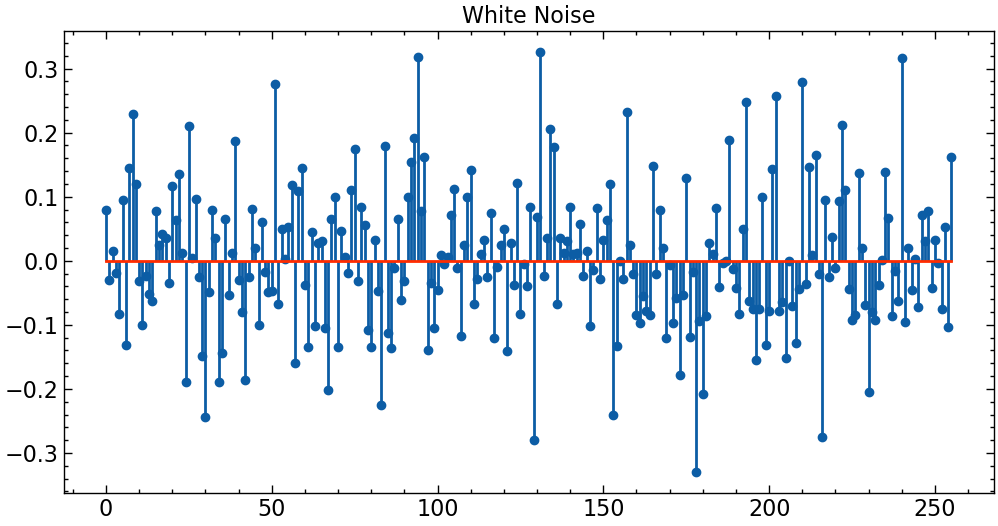

In [3]:
# --- Parameters ---
N = 256         # Number of samples
Fe = 10000       # Sampling frequency (10 kHz)
sigma2 = 0.01     # Variance (Power)
sigma = np.sqrt(sigma2)

# 1. White Gaussian Noise (Bruit blanc gaussien)
# Generate noise with mean 0 and standard deviation sigma
bruit_blanc = sigma * np.random.randn(N)

plt.figure(figsize=(12, 6))
plt.stem(bruit_blanc); plt.title("White Noise")
plt.show()

$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 1 :** </span> Réaliser un processus $\operatorname{AR}(1)$ avec un paramètre $a$ et une puissance d'innovation $\sigma^2$ donnés.

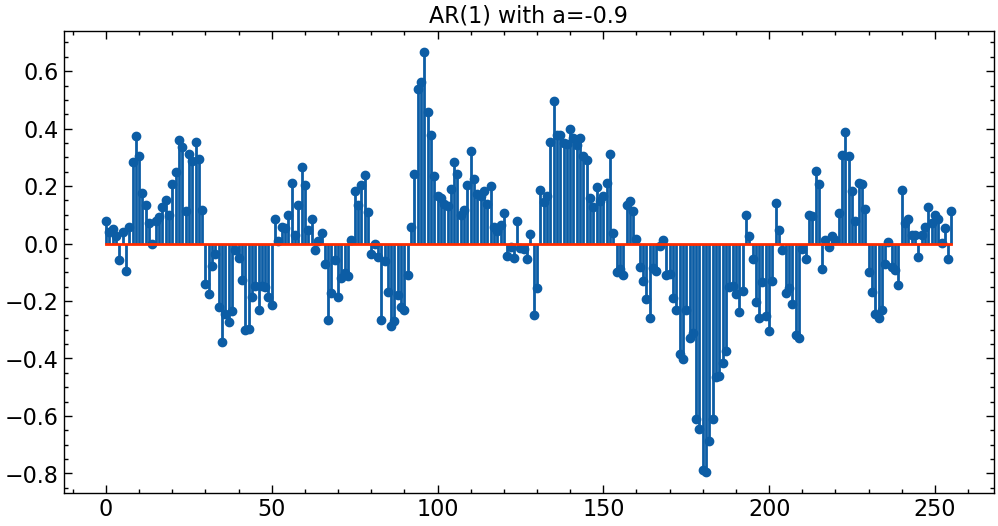

In [4]:
# 2. AR(1) Process
# Model: x[n] + a*x[n-1] = w[n]  ->  H(z) = 1 / (1 + a*z^-1)
a = -0.9
# Filter: b (numerator) = [1], a (denominator) = [1, a]
ar1 = s.lfilter([1], [1, a], bruit_blanc)

plt.figure(figsize=(12, 6))
plt.stem(ar1); plt.title(f"AR(1) with a={a}")
plt.show()

$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 2 :** </span> Réaliser une sinusoïde à phase aléatoire de fréquence réduite $\nu_0$ et d'amplitude $A$ données.

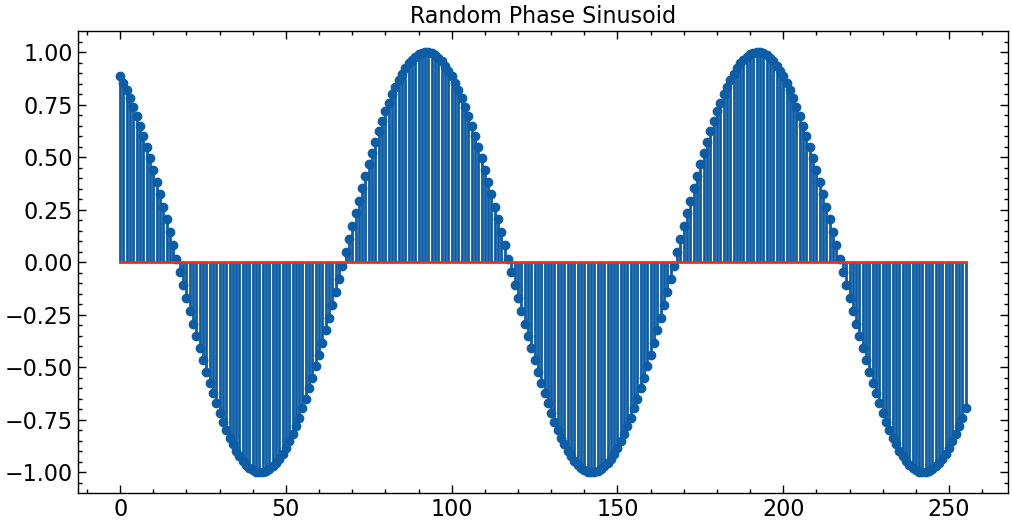

In [5]:
# 3. Random Phase Sinusoid
# x[n] = A * sin(2*pi*nu0*n + phi)
A = 1.0
nu0 = 0.01 # Normalized frequency (f0/Fe)
phi = np.random.uniform(0, 2*np.pi)
n = np.arange(N)
sinusoide = A * np.sin(2 * np.pi * nu0 * n + phi)

plt.figure(figsize=(12, 6))
plt.stem(sinusoide); plt.title("Random Phase Sinusoid")
plt.show()

<a id="s1-autocorr-b"></a>
### Estimateur biaisé de l'autocorrélation

The formula for the biased estimator for a lag $p$ is:

$\hat{R}_{xx}[p] = \frac{1}{N} \sum_{n=0}^{N−1−p}x[n]⋅x[n+p]$
      

Écrire la fonction décrite de la manière suivante :

In [6]:
def biaisedCrossCorr(x: np.ndarray, pmax: int = None):
    """Computation of the biaised cross correlation of a given signal x

    Inputs
    ----------
    x : np.ndarray
        Vector of signal samples
    pmax : int
        Maximal amount of delay to be considered (optionnal, default set to len(x)-1)

    Returns
    -------
    Cx : np.ndarray
        Vector of cross correlation samples from shifts varying from 0 to pmax
    p : np.ndarray
        Vector of corresponding shifts
    """
    N = len(x)
    if pmax is None:
        pmax = N - 1
    
    Cx = np.zeros(pmax + 1)
    
    # We compute the correlation for lags 0 to pmax
    for p in range(pmax + 1):
        # Vectorized calculation is faster than a loop over N
        # x[0 : N-p]  dot  x[p : N]
        Cx[p] = np.dot(x[0:N-p], x[p:N]) / N
        
    lags = np.arange(pmax + 1)
    return Cx, lags


Liste non exhaustive de questions que l'on peut se poser :

- Comment générer une réalisation de bruit blanc de variance donnée ?
- Comment générer une réalisation de processus $\operatorname{AR}(1)$ avec un paramètre $a$ et une puissance d'innovation $\sigma^{2}$ donnés ?
- Comment générer une réalisation de sinusoïde à phase aléatoire de fréquence réduite et d'amplitude données ?
- Pour quelles valeurs du retard $p$ peut-on estimer l'estimateur biaisé de l'autocorrélation ?
- Que se passe-t-il si le signal étudié contient une composante continue, traduisant un processus non centré ? Comment estimer correctement son autocorrélation ?
- La valeur d'autocorrélation estimée prise pour un décalage $p=0$ est-elle en accord avec ce que renvoie la fonction `numpy.var` ?
- Pour des processus dont on connait l'autocorrélation théorique, cet estimateur biaisé semble-t-il converger quand le nombre d'échantillons du signal devient grand ?
- Peut-on observer l'effet du biais avec certains exemples ?
- Cet estimateur biaisé est-il plutôt adéquat pour les sons voisés ou pour les sons non voisés ?  

$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 3 :** </span> Tester votre fonction sur les signaux artificiels réalisés dans la section précédente et discuter les résultats.

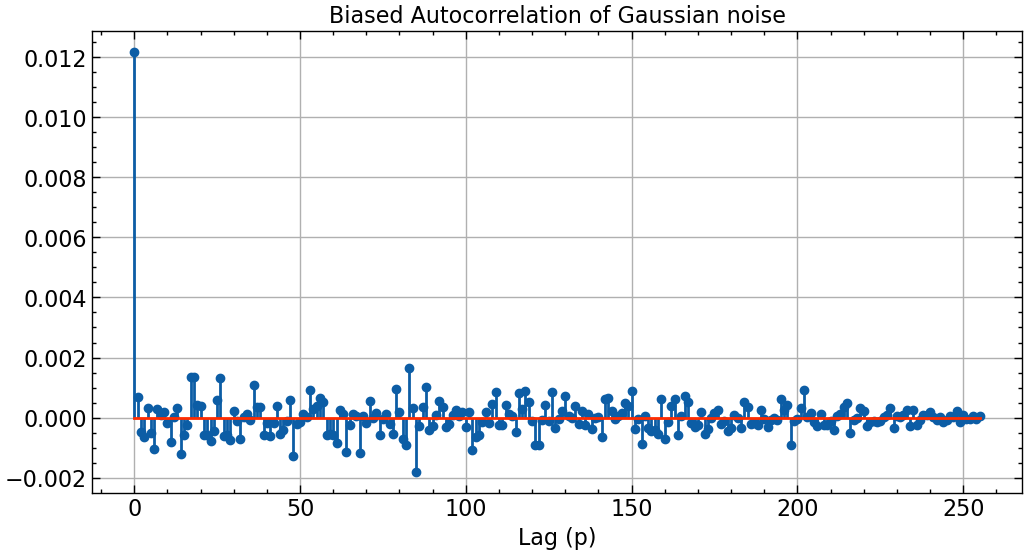

0.012180840026786157


In [7]:
# Test on Gaussian noise
pmax = None
Cx_biased, lags = biaisedCrossCorr(bruit_blanc, pmax)

plt.figure(figsize=(12, 6))
plt.stem(lags, Cx_biased)
plt.title("Biased Autocorrelation of Gaussian noise")
plt.xlabel("Lag (p)")
plt.grid()
plt.show()

print(np.var(bruit_blanc))

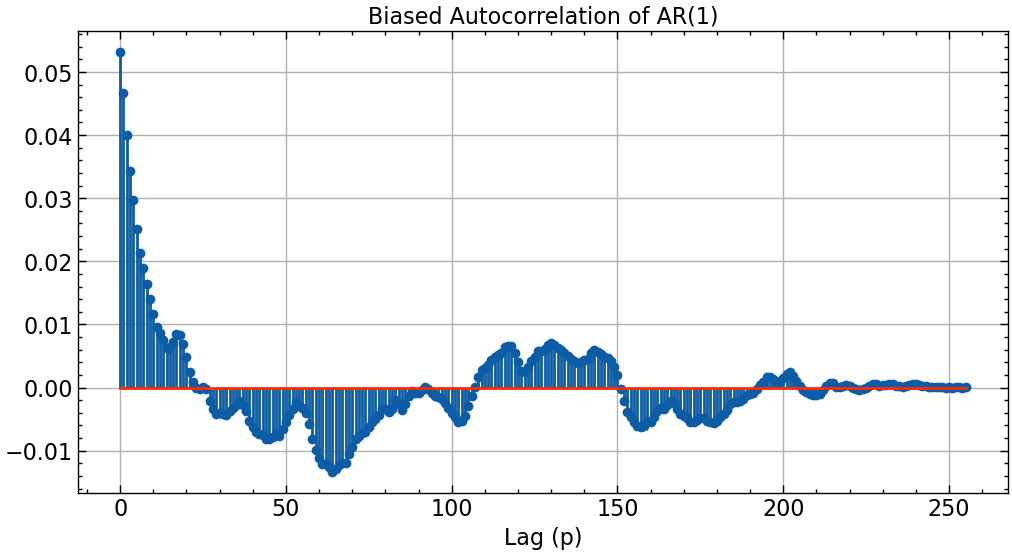

0.05313924725428791


In [8]:
# Test on AR(1)
pmax = None
Cx_biased, lags = biaisedCrossCorr(ar1, pmax)

plt.figure(figsize=(12, 6))
plt.stem(lags, Cx_biased)
plt.title("Biased Autocorrelation of AR(1)")
plt.xlabel("Lag (p)")
plt.grid()
plt.show()

print(np.var(ar1))

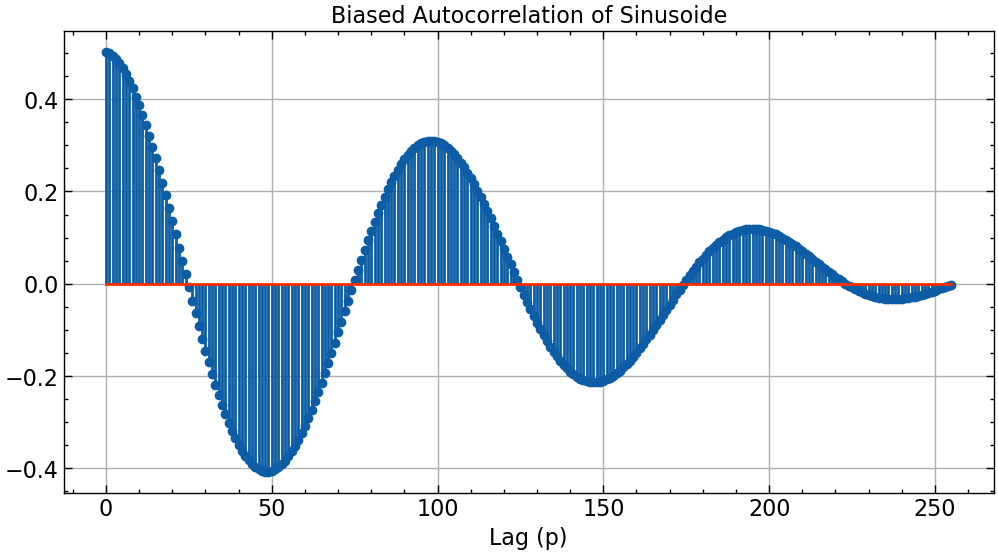

0.4978495640425975


In [9]:
# Test on Random Phase Sinusoid
pmax = None
Cx_biased, lags = biaisedCrossCorr(sinusoide, pmax)

plt.figure(figsize=(12, 6))
plt.stem(lags, Cx_biased)
plt.title("Biased Autocorrelation of Sinusoide")
plt.xlabel("Lag (p)")
plt.grid()
plt.show()

print(np.var(sinusoide))

<a id="s1-autocorr-nb"></a>
### Estimateur non-biaisé de l'autocorrélation

Écrire la fonction décrite de la manière suivante :

In [10]:
def unbiaisedCrossCorr(x: np.ndarray, pmax: int = None):
    """Computation of the unbiaised cross correlation of a given signal x

    Inputs
    ----------
    x : np.ndarray
        Vector of signal samples
    pmax : int
        Maximal amount of delay to be considered (optionnal, default set to len(x)-1)

    Returns
    -------
    Cx : np.ndarray
        Vector of cross correlation samples from shifts varying from 0 to pmax
    p : np.ndarray
        Vector of corresponding shifts
    """
    N = len(x)
    if pmax is None:
        pmax = N - 1
        
    Cx = np.zeros(pmax + 1)
    
    for p in range(pmax + 1):
        # Normalization by (N-p) instead of N
        if N - p > 0:
            Cx[p] = np.dot(x[0:N-p], x[p:N]) / (N - p)
        else:
            Cx[p] = 0
            
    lags = np.arange(pmax + 1)
    return Cx, lags


$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 4 :** </span> Tester votre fonction sur vos signaux artificiels et discuter les résultats (on comparera notamment avec les résultats de la section précédente).

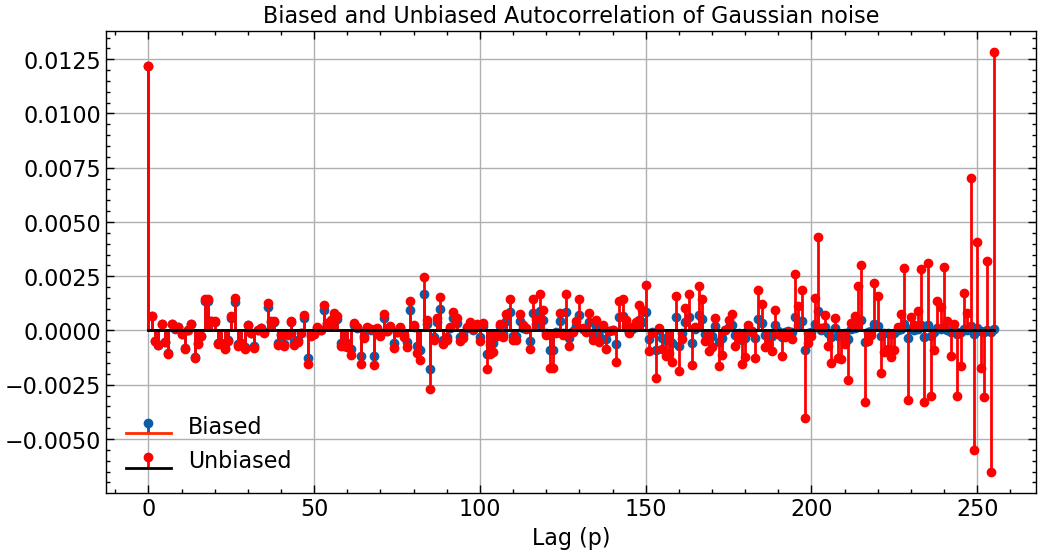

In [11]:
# Test on Gaussian noise
pmax = None
Cx_biased, lags1 = biaisedCrossCorr(bruit_blanc, pmax)
Cx_unbiased, lags2 = unbiaisedCrossCorr(bruit_blanc, pmax)

plt.figure(figsize=(12, 6))
plt.stem(lags1, Cx_biased, label='Biased')
plt.stem(lags2, Cx_unbiased, label='Unbiased', markerfmt='red', basefmt='k-', linefmt='r-')
plt.title("Biased and Unbiased Autocorrelation of Gaussian noise")
plt.xlabel("Lag (p)")
plt.legend()
plt.grid()
plt.show()

>The autocorellation of the white noise is ideally 0 when p different of 0. That's why tring to unbiaised it makes it diverge, it exacerbates that error.

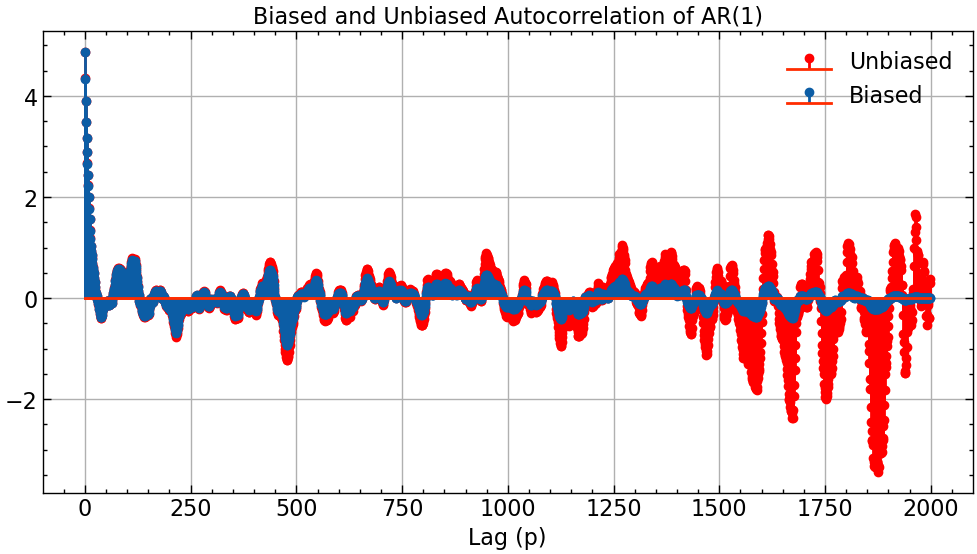

In [30]:
# Test on AR(1)
pmax = None
Cx_biased, lags1 = biaisedCrossCorr(ar1, pmax)
Cx_unbiased, lags2 = unbiaisedCrossCorr(ar1, pmax)

plt.figure(figsize=(12, 6))
plt.stem(lags2, Cx_unbiased, label='Unbiased', markerfmt='red', linefmt='red')
plt.stem(lags1, Cx_biased, label='Biased')
plt.title("Biased and Unbiased Autocorrelation of AR(1)")
plt.xlabel("Lag (p)")
plt.legend()
plt.grid()
plt.show()

>As said earlier as p goes higher, the autocorrelation converges toward a white noise behavior. That's why at the end it also goes off.

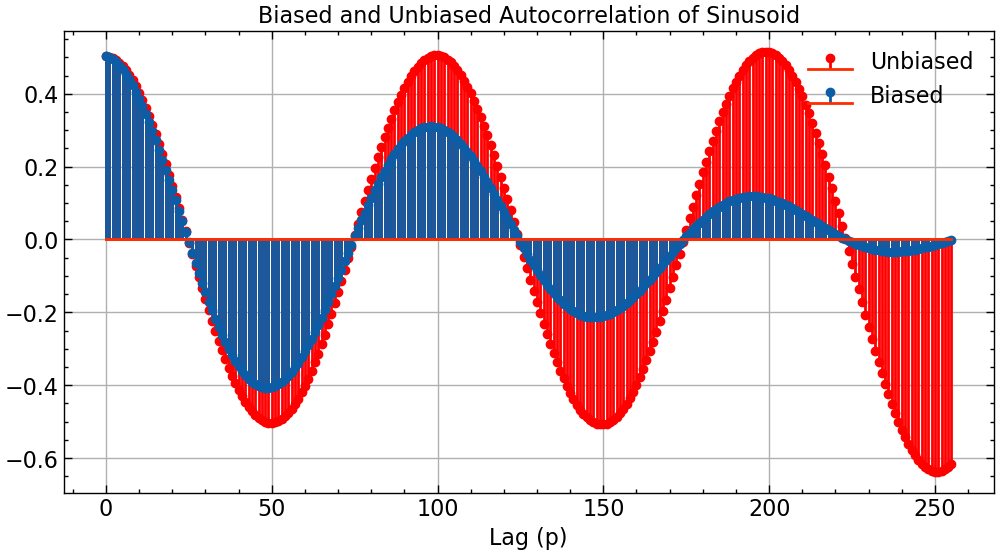

In [43]:
# Test on Sinusoid
pmax = None
Cx_biased, lags1 = biaisedCrossCorr(sinusoide, pmax)
Cx_unbiased, lags2 = unbiaisedCrossCorr(sinusoide, pmax)

plt.figure(figsize=(12, 6))
plt.stem(lags2, Cx_unbiased, label='Unbiased', markerfmt='red', linefmt='red')
plt.stem(lags1, Cx_biased, label='Biased')
plt.title("Biased and Unbiased Autocorrelation of Sinusoid")
plt.xlabel("Lag (p)")
plt.legend()
plt.grid()
plt.show()

>In this case, the non biased signal works really well (we see some periods of the cosine) except on the few last value (too few value to be precise).

Liste non exhaustive de questions que l'on peut se poser :
- Pour des processus dont on connaît l'autocorrélation théorique, cet estimateur non biaisé semble-t-il converger quand le nombre d'échantillons du signal devient grand ? Observe-ton effectivement un biais nul ?
- Peut-on observer l'effet de la variance de l'estimateur avec certains exemples ?
- Cet estimateur non biaisé est-il plutôt adéquat pour les sons voisés ou pour les sons non voisés ?  


<a id="s1-voise"></a>
### Etablissement d'un critère pour le caractère voisé

$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 5 :** </span> Visualiser (et écouter) un signal voisé et déterminer sa pseudo-période.

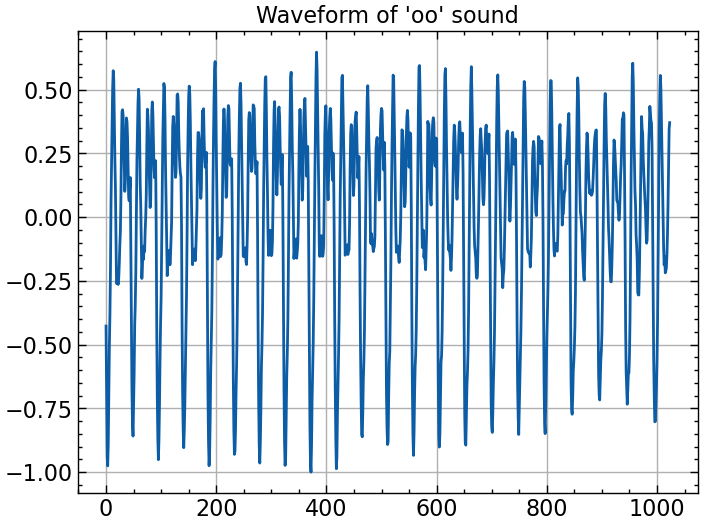

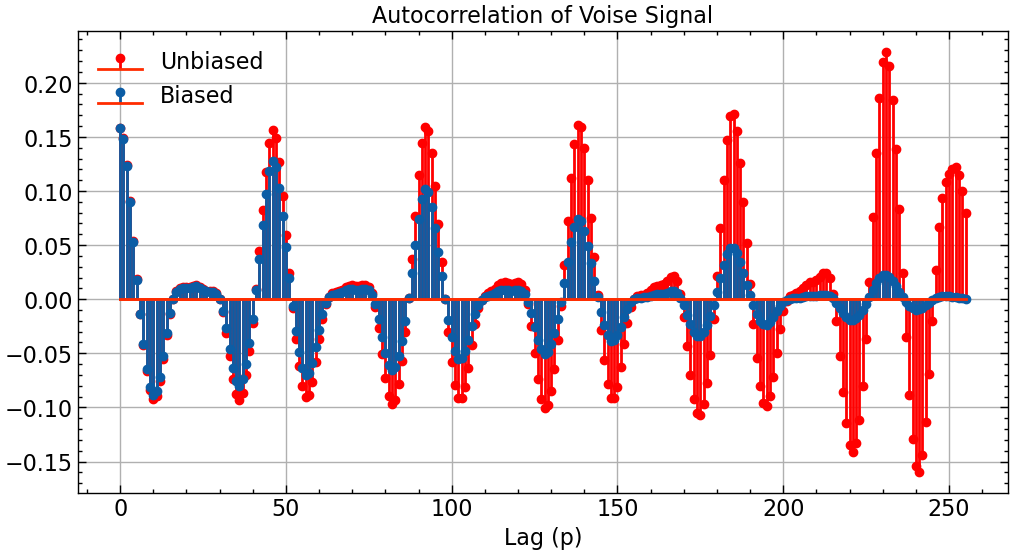

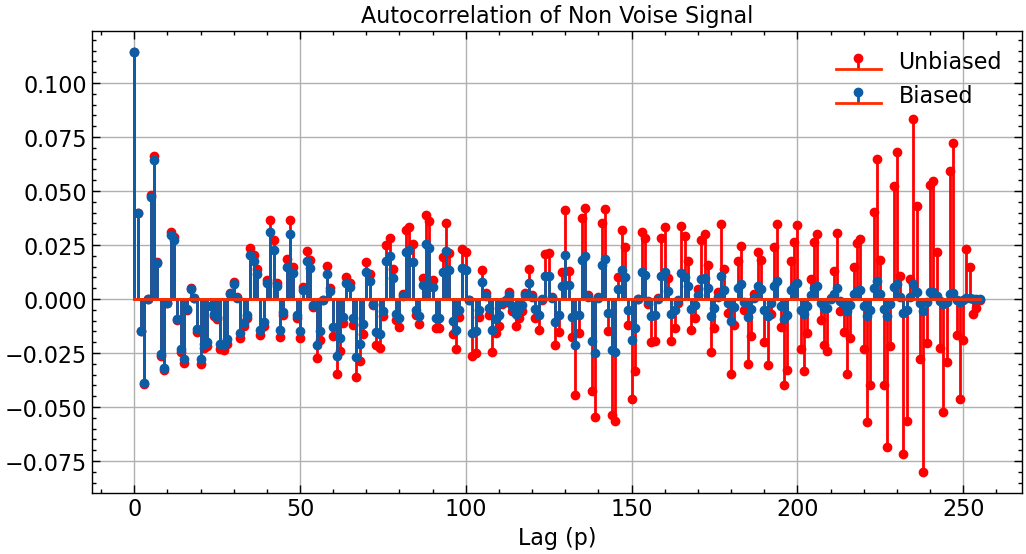

In [44]:
sig, sr = sf.read('sound_files/voise_oo.flac')
x_voiced = sig[0:256] # Take a small block

plt.plot(sig)
plt.title("Waveform of 'oo' sound")
plt.grid()
plt.show()

Cx_biased, lags_biased = biaisedCrossCorr(x_voiced, pmax)
Cx_unbiased, lags_unbiased = unbiaisedCrossCorr(x_voiced, pmax)

plt.figure(figsize=(12, 6))
plt.stem(lags_unbiased, Cx_unbiased, markerfmt='red', linefmt='red', label='Unbiased')
plt.stem(lags_biased, Cx_biased, label='Biased')
plt.title("Autocorrelation of Voise Signal")
plt.xlabel("Lag (p)")
plt.legend()
plt.grid()
plt.show()

sig2, sr2 = sf.read('sound_files/nonvoise_kss.flac')
x_voiced2 = sig2[0:256]

Cx_biased2, lags_biased2 = biaisedCrossCorr(x_voiced2, pmax)
Cx_unbiased2, lags_unbiased2 = unbiaisedCrossCorr(x_voiced2, pmax)

plt.figure(figsize=(12, 6))
plt.stem(lags_unbiased2, Cx_unbiased2, markerfmt='red', linefmt='red',  label='Unbiased')
plt.stem(lags_biased2, Cx_biased2, label='Biased')
plt.title("Autocorrelation of Non Voise Signal")
plt.xlabel("Lag (p)")
plt.legend()
plt.grid()
plt.show()

Le caractère voisé ou non se caractérise par l'aspect quasi-périodique ou non du signal. Il se voit en comparant l'amplitude du second maximum de la fonction d'autocorrélation au maximum de la fonction d'autocorrélation. 

1. Représenter la fonction d'autocorrélation normalisée par son maximum.
2. À partir de l'étude de plusieurs signaux voisés et non voisés, déterminer un seuil permettant de distinguer les signaux voisés des nons voisés.
3. On écrira la fonction `isvoiced` testant le caractère voisé d'un signal.

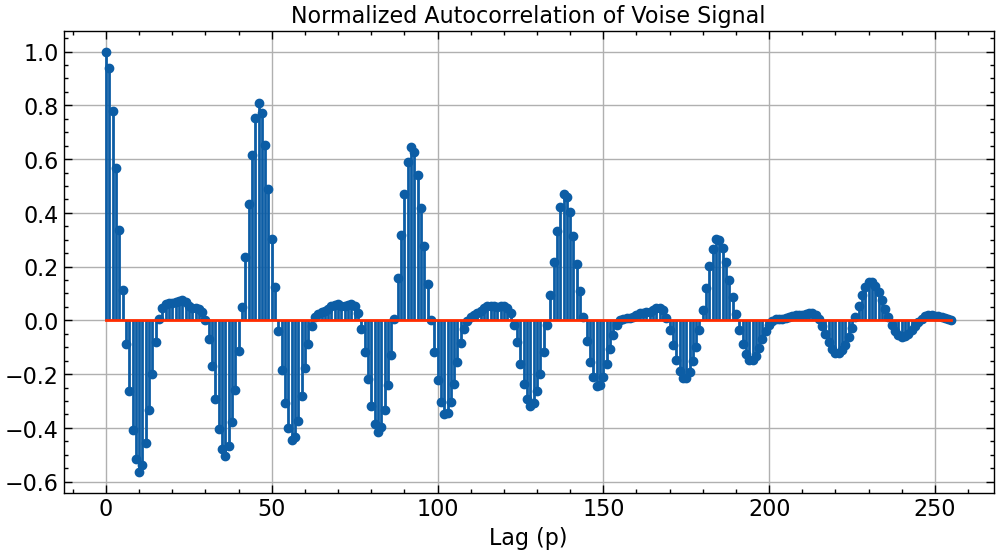

1.0 0.9379354105256897


In [45]:
def normalizedCrossCorr(x: np.ndarray, pmax: int = None):
    N = len(x)
    if pmax is None:
        pmax = N - 1
    
    Cx = np.zeros(pmax + 1)
    
    for p in range(pmax + 1):
        Cx[p] = np.dot(x[0:N-p], x[p:N]) / N
    
    Cmax = np.max(Cx)
    Cx = Cx/Cmax
    lags = np.arange(pmax + 1)
    return Cx, lags

sig, sr = sf.read('sound_files/voise_oo.flac')
x_voiced = sig[0:256] 

Cx, lags = normalizedCrossCorr(x_voiced, pmax)

plt.figure(figsize=(12, 6))
plt.stem(lags, Cx)
plt.title("Normalized Autocorrelation of Voise Signal")
plt.xlabel("Lag (p)")
plt.grid()
plt.show()

print(np.max(Cx), np.max(Cx[1:]))

In [34]:
def isvoiced(X: np.ndarray):
    """Determines if a sound is voiced based on its cross correlation values.

    Inputs
    ----------
    X : np.ndarray
        Vector of signal samples

    Returns
    -------
    bool : bool
        1 (true) if the sound is voiced, 0 (false) otherwise.
    """
    
    # 1. Calculate Biased Autocorrelation
    pmax = len(X) - 1
    Cx, lags = biaisedCrossCorr(X, pmax)
    
    # 2. Normalize so Cx[0] = 1
    if Cx[0] == 0: return 0 # Silence
    Cx_norm = Cx / Cx[0]
    
    # 3. Define search range for human pitch
    # Typical pitch: 50Hz to 400Hz
    # Lag = Fe / F
    min_lag = int(Fe / 400)  # e.g., 25 samples at 10kHz
    max_lag = int(Fe / 50)   # e.g., 200 samples at 10kHz
    
    # Safety check for short signals
    if max_lag >= len(Cx_norm):
        max_lag = len(Cx_norm) - 1
        
    # 4. Find max in that range
    # We look for the maximum correlation value within the valid pitch lags
    peak_val = np.max(Cx_norm[min_lag:max_lag])
    
    # 5. Thresholding
    # Threshold often determined empirically (e.g., 0.4)
    threshold = 0.4 
    
    return bool(peak_val > threshold)

$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 6 :** </span> Tester la fonction `isvoiced` sur un signal voisé et sur un signal non voisé.

<a id="s1-further"></a>
### Pour aller plus loin

 
- Afin de réduire la complexité, réaliser l'estimateur de la fonction d'autocorrélation à partir d'une DFT et IDFT.  


In [35]:
def fastAutocorr(x):
    # Zero padding to length 2N-1 to avoid circular convolution
    n = len(x)
    size = 2 * n - 1
    
    # FFT
    # fft(x, size) automatically pads with zeros
    X_f = np.fft.fft(x, size)
    
    # Power Spectral Density (approx)
    S_f = np.abs(X_f)**2
    
    # IFFT to get correlation
    R = np.fft.ifft(S_f).real
    
    # Normalize (biased)
    R = R / n
    
    # Return only the first N lags (positive lags)
    return R[:n]

***

<a id="seance2"></a>
## Séance 2 : Analyse spectrale

> $\quad$  
> **Objectifs de séance :** 
> - Estimation de la densité spectrale de puissance (DSP) d'un signal
> - Caractérisation d'un processus aléatoire dans le domaine fréquentiel
> - Effet du fenêtrage  
> $\quad$

<a id="s2-estim"></a>
### Deux approches pour un même estimateur (ou presque)

Pour estimer la *densité spectrale de puissance* (DSP) d'un processus $\mathsf{X}$ dont on a mesuré une trajectoire sur un nombre fini $N$ d'échantillons, deux approches sont possibles :  
- **corrélogramme :** utiliser l'estimateur <span style="color:#b10043"> **biaisé** </span> d'autocorrélation (*on pourra essayer avec l'estimateur non biaisé et voir que ça ne fonctionne pas très bien...*) et calculer sa transformée de Fourier
- **périodogramme :** calculer la TFTD des échantillons dont on dispose, prendre la valeur absolue au carré et diviser par le nombre d'échantillons  

Dans la pratique, on ne peut pas estimer à la DSP pour toutes les valeurs de fréquence réduite $\nu$ (car la variable est continue). On s'intéresse donc à la DSP pour un ensemble fini de valeurs de fréquences réduites. Il est intéressant de tirer parti de l'algorithme FFT pour les calculs de transformées de Fourier discrètes, avec un paramètre $N_{fft}$ à choisir.

Ecrire les fonctions réalisant l'estimation de la DSP (une pour chaque méthode) décrites de la manière suivante : 

In [36]:
import numpy as np

def psdestimator_corr(x: np.ndarray, Nfft: int = None):
    N = len(x)
    if Nfft is None:
        Nfft = 2 * N - 1

    Cx_pos, _ = biaisedCrossCorr(x, pmax=N-1)

    Cx_neg = Cx_pos[1:][::-1]
    R_xx = np.concatenate((Cx_neg, Cx_pos))

    PSD = np.abs(np.fft.fft(R_xx, Nfft))

    nu = np.fft.fftfreq(Nfft)

    mask = (nu >= 0)
    return PSD[mask], nu[mask]


In [37]:
def psdestimator_per(x: np.ndarray, Nfft: int = None):
    """Computation of the PSD estimator using the periodogram method"""
    N = len(x)
    if Nfft is None:
        Nfft = N
        
    X_f = np.fft.fft(x, Nfft)
    
    PSD = (np.abs(X_f)**2) / N
    
    nu = np.fft.fftfreq(Nfft)
    
    mask = nu >= 0
    return PSD[mask], nu[mask]

$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 7 :** </span> Tester vos fonctions sur un bruit blanc, un processus $\operatorname{AR}(1)$ et une sinusoïde à phase aléatoire. Discuter les résultats et comparer les résultats des deux méthodes.

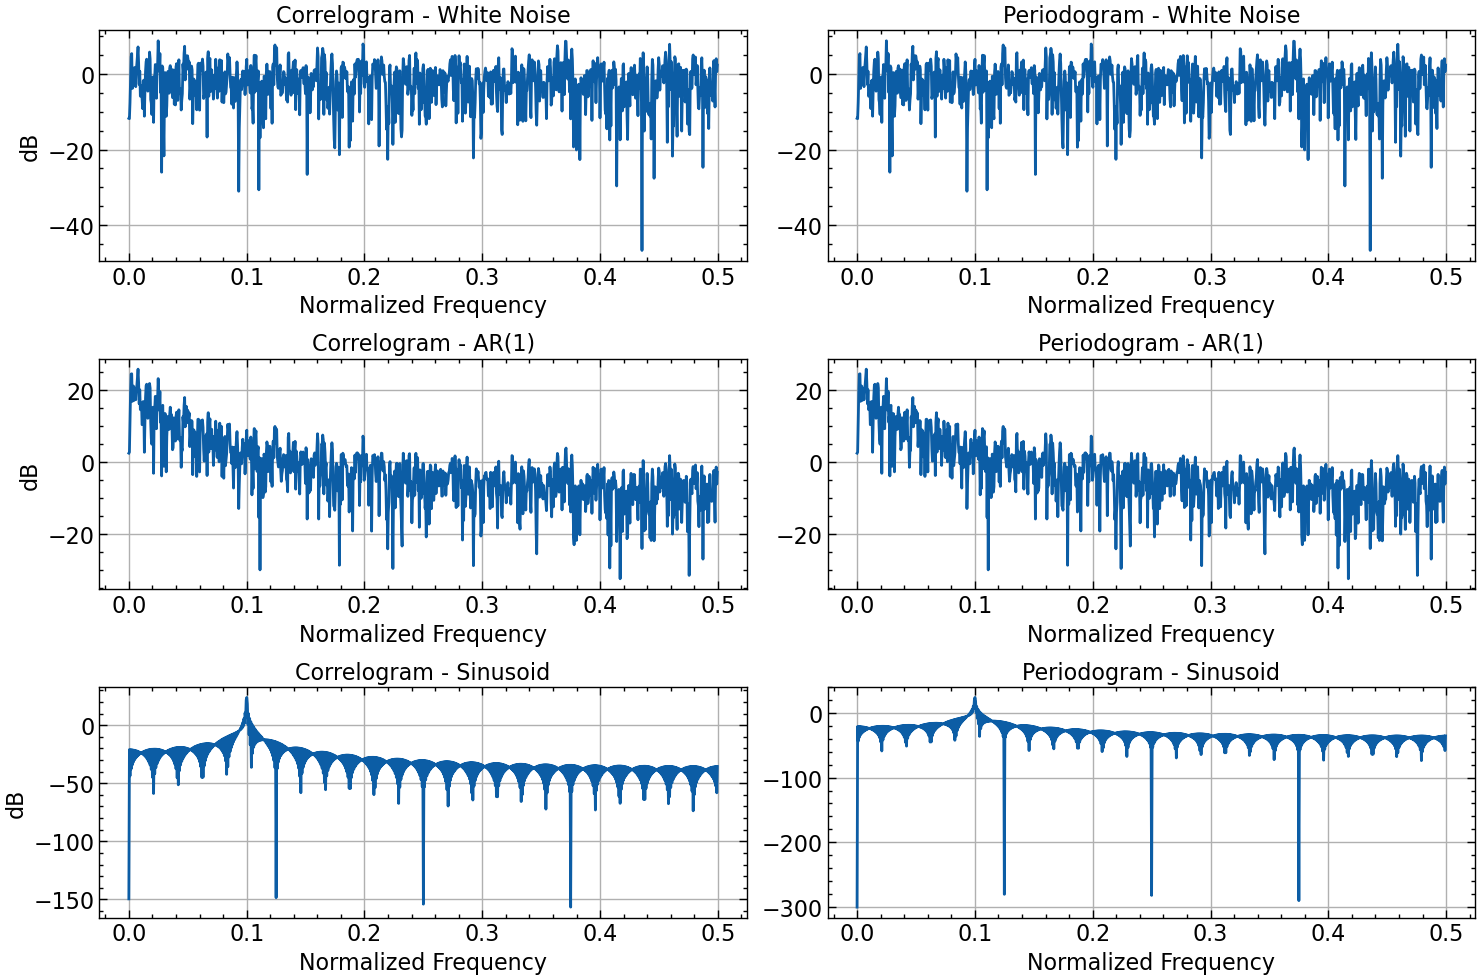

In [38]:
# Signal Generation
N = 1000
sigma = 1.0
# 1. White Noise
bruit = sigma * np.random.randn(N)
# 2. AR(1)
a = -0.9 
ar1 = s.lfilter([1], [1, a], bruit)
# 3. Sinusoid
nu0 = 0.1
sinus = np.sin(2 * np.pi * nu0 * np.arange(N) + np.random.rand()*2*np.pi)

# PSD Calculation
Nfft = 2048

# Calculate
P_corr_noise, f_corr = psdestimator_corr(bruit, Nfft)
P_per_noise, f_per   = psdestimator_per(bruit, Nfft)

P_corr_ar, f_corr    = psdestimator_corr(ar1, Nfft)
P_per_ar, f_per      = psdestimator_per(ar1, Nfft)

P_corr_sin, f_corr   = psdestimator_corr(sinus, Nfft)
P_per_sin, f_per     = psdestimator_per(sinus, Nfft)

# Plotting
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

# White Noise
axes[0,0].plot(f_corr, 10*np.log10(P_corr_noise)); axes[0,0].set_title("Correlogram - White Noise")
axes[0,0].set_ylabel("dB")
axes[0,1].plot(f_per, 10*np.log10(P_per_noise));   axes[0,1].set_title("Periodogram - White Noise")

# AR(1)
axes[1,0].plot(f_corr, 10*np.log10(P_corr_ar));    axes[1,0].set_title("Correlogram - AR(1)")
axes[1,0].set_ylabel("dB")
axes[1,1].plot(f_per, 10*np.log10(P_per_ar));      axes[1,1].set_title("Periodogram - AR(1)")

# Sinusoid
axes[2,0].plot(f_corr, 10*np.log10(P_corr_sin));   axes[2,0].set_title("Correlogram - Sinusoid")
axes[2,0].set_ylabel("dB")
axes[2,1].plot(f_per, 10*np.log10(P_per_sin));     axes[2,1].set_title("Periodogram - Sinusoid")

for ax in axes.flat: ax.grid(); ax.set_xlabel("Normalized Frequency")
plt.tight_layout()
plt.show()

>First, we can notice that the left column (Correlogram) and the right column (Periodogram) are virtually identical in shape for all signals. This confirms the theory that the Discrete Fourier Transform of the autocorrelation is mathematically equivalent to the squared magnitude of the signal's Fourier Transform. The only minor differences (like the depth of the nulls in the sinusoid plot) are due to numerical precision
>
>White Noise :
>
>White noise has a flat Power Spectral Density (PSD). We expect a horizontal line indicating equal energy across all frequencies. However the plot shows a highly erratic, jagged curve ("grass") fluctuating around a mean value. This visualizes the fact that the Periodogram/Correlogram is an inconsistent estimator. Even if we increased the number of samples N, the variance of the estimate would not decrease; the "grass" would just become denser. The fluctuations are proportional to the value of the PSD itself.
>
>AR(1) Process :
>
>We generated an AR(1) process with a parameter a=−0.9. This creates a filter pole at z=0.9, which is a low-pass filter. We expect high energy at low frequencies (ν≈0) and a smooth decay as frequency increases to 0.5. We can clearly see the global low-pass trend: the energy is highest at the left (approx 25 dB) and drops off towards the right (approx -10 dB). Just like with the white noise, the "grass" (statistical variance) is superimposed on the theoretical spectral shape.
>
>Sinusoid :
>
>A pure sine wave at a single frequency corresponds to a Dirac delta function (a single spike) in the spectrum. We see a very sharp, distinct peak exactly at the normalized frequency 0.1, which matches the parameter ν0​ used in the generation code. The peak is not just a single line; it has a "skirt" of smaller ripples fading away. It occurs because we are observing the signal through a finite rectangular window. The Fourier transform of a rectangular window is a sinc-like function, which creates these side lobes. Unlike the random signals above, this spectrum is very clean and structured because the signal is deterministic.



Liste non exhaustive des questions que l'on peut se poser :
- Pour la méthode du corrélogramme, quelles valeurs de décalage doit-on prendre en compte ? 
- Pour la méthode du corrélogramme, comment organiser le vecteur de coefficients d'autocorrélation pour que les coefficients calculés par la FFT renvoient une valeur réelle et positive ? 
- Pour la méthode du périodogramme ? Quel nombre d'échantillon doit servir pour la normalisation ? $N$ ou $N_{fft}$ ?
- Quelles sont les fréquences réduites correspondant aux coefficients renvoyés par l'algorithme FFT ?
- Pourquoi peut-on réduire l'affichage à une fréquence réduite comprise entre 0 et 1/2 ? Comment faire ?
- Cet estimateur a-t-il une bonne résolution fréquentielle ? On le testera en prenant comme signal d'entrée la superposition de deux sinusoïdes de fréquences réduites $\nu_1$ et $\nu_2$ très proches.

<a id="s2-wk"></a>
### Fiabilité de l'estimation spectrale

Grâce au théorème de Wiener-Kintchine, on sait que l'estimateur de la DSP est asymptotiquement non biaisé, c'est-à-dire qu'à mesure que le nombre d'échantillon $N$ croît, son espérance s'approche de la véritable DSP.  
Néanmois, à moins que le processus étudié ne soit totalement prédictible (*signaux à très forte structure par exemple*), la variance de l'estimateur de DSP ne converge pas vers zéro quand le nombre d'échantillons croît (il n'y a pas de convergence de l'estimateur en moyenne quadratique).

La seule possibilité pour réduire la variance est alors de tronquer les $N$ échantillons dont on dispose en parts avec lesquelles on estime la DSP et, finalement, moyenner les DSP obtenues. Avec $K$ parties décorrélées, on divise la variance par $K$.

$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 8 :** </span> Adapter les fonctions d'estimation de la DSP pour qu'elle prenne $K$ en paramètre optionnel et réalise un moyennage le cas échéant.

In [19]:
import numpy as np

def psdestimator_per_avg(x: np.ndarray, Nfft: int = None, K: int = 1):
    """
    Computation of the PSD estimator using the periodogram method with Averaging.
    """
    N_total = len(x)
    L = N_total // K  # Length of one block
    
    if Nfft is None:
        Nfft = L
        
    # Truncate signal to be a multiple of K
    x = x[:K*L]
    
    # Initialize accumulator
    # Size matches rfft output: Nfft//2 + 1
    PSD_avg = np.zeros(Nfft // 2 + 1)
    
    # Loop over blocks
    for i in range(K):
        block = x[i*L : (i+1)*L]
        
        # Compute FFT of the block
        X_f = np.fft.fft(block, Nfft)
        
        # Compute Periodogram for this block
        P_block = (np.abs(X_f)**2) / L
        
        # Add to accumulator (positive frequencies only)
        # We take the first Nfft//2 + 1 elements
        P_pos = P_block[:Nfft//2 + 1]
            
        PSD_avg += P_pos

    # Average
    PSD_avg /= K
    
    # Frequency axis
    # Use rfftfreq to get exactly Nfft//2 + 1 points (0 to 0.5 inclusive)
    nu = np.fft.rfftfreq(Nfft)
    
    return PSD_avg, nu

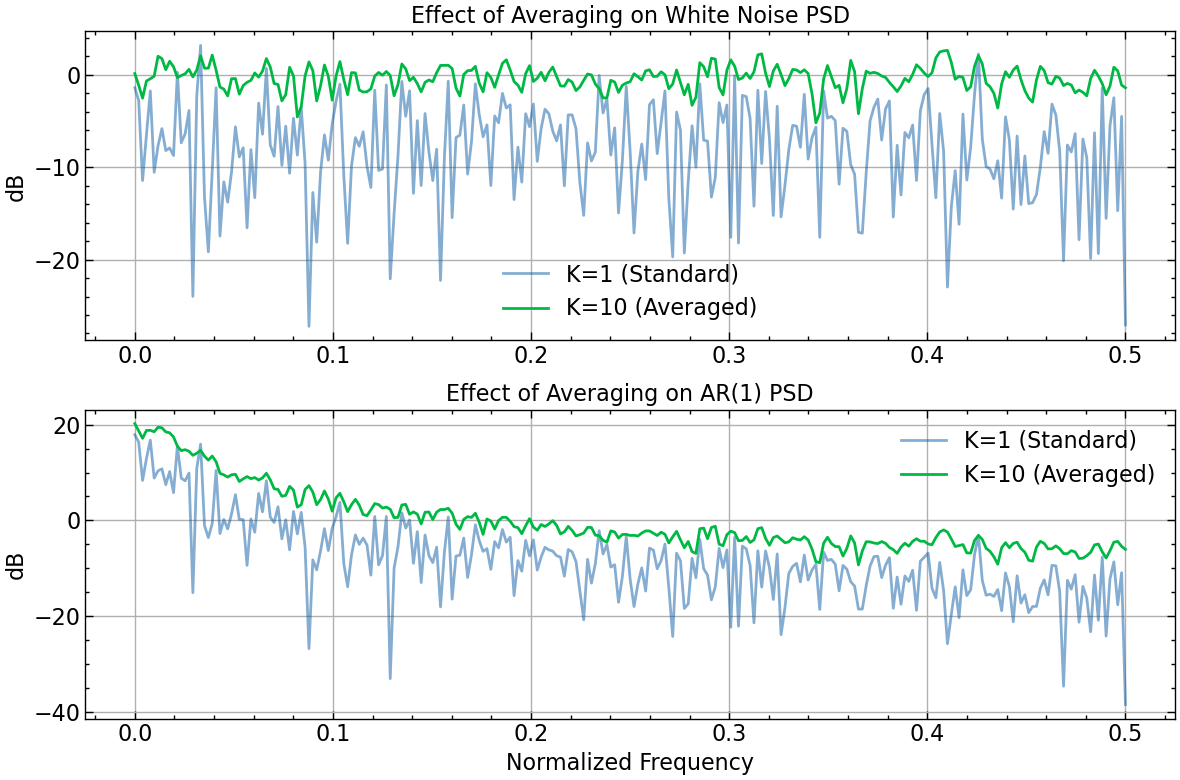

In [55]:
# --- Setup ---
N = 2000  # Increased sample count to allow splitting
bruit = np.random.randn(N)
ar1 = s.lfilter([1], [1, -0.9], bruit)
Nfft = 512

# --- Compute ---
# Without averaging (High Variance)
P_noise_1, f_1 = psdestimator_per_avg(bruit, Nfft, K=1)
P_ar_1, _      = psdestimator_per_avg(ar1,   Nfft, K=1)

# With averaging (Lower Variance, Lower Resolution)
P_noise_10, f_10 = psdestimator_per_avg(bruit, Nfft, K=10)
P_ar_10, _       = psdestimator_per_avg(ar1,   Nfft, K=10)

# --- Plot ---
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(f_1, 10*np.log10(P_noise_1), label='K=1 (Standard)', alpha=0.5)
plt.plot(f_10, 10*np.log10(P_noise_10), label='K=10 (Averaged)', linewidth=2)
plt.title("Effect of Averaging on White Noise PSD")
plt.legend(); plt.grid(); plt.ylabel("dB")

plt.subplot(2, 1, 2)
plt.plot(f_1, 10*np.log10(P_ar_1), label='K=1 (Standard)', alpha=0.5)
plt.plot(f_10, 10*np.log10(P_ar_10), label='K=10 (Averaged)', linewidth=2)
plt.title("Effect of Averaging on AR(1) PSD")
plt.legend(); plt.grid(); plt.xlabel("Normalized Frequency"); plt.ylabel("dB")

plt.tight_layout()
plt.show()

>Variance: With K=10, the curve is much smoother. The "variance" of the estimator has been divided by K.
>
>Bias/Resolution: By splitting N samples into blocks of size N/K, we lose frequency resolution. This is the Bias-Variance tradeoff.

Liste non exhaustive de questions que l'on peut se poser :
- Comment la variance d'estimation de la DSP d'un bruit blanc évolue-t-elle avec un nombre d'échantillon $N$ croissant ?   
Accord entre théorie et simulation ? 
- Comment la variance d'estimation de la DSP d'un processus $\operatorname{AR}(1)$ évolue-t-elle avec un nombre d'échantillon $N$ croissant ?   
Accord entre théorie et simulation ? 
- Comment la variance d'estimation de la DSP d'une sinusoïde à phase aléatoire évolue-t-elle avec un nombre d'échantillon $N$ croissant ?   
Accord entre théorie et simulation ? 
- Parvient-on à améliorer la variance d'estimation avec un moyennage ? Si oui, quel est le prix à payer ? 

<a id="s2-fenetrage"></a>
### Choix d'une fenêtre temporelle

Selon la nature spectrale du signal observé ou son utilisation, on peut vouloir pondérer les échantillons dont on dispose à l'aide de différentes fenêtres.  
On n'hésitera pas à jeter un oeil à `numpy.window` pour l'implémentation.

| Nom          | $f_N[n]$ pour $n \in [0, N-1]$                                         | Largeur de lobe principal | Pente asymptotique (dB/décade) | Pic secondaire (dB) |
|:--------------:|:----------------------------------------------------------------------:|:----------------------------:|:-------------------------------:|:---------------------:|
| Rectangulaire | $1$                                                                  | $2/N$                      | $-20$                         | $-13.3$             |
| Triangulaire  | $1 - \operatorname{abs}\left(1 - \frac{2n + 1}{N}\right)$                                               | $4/N$                      | $-40$                         | $-26.5$             |
| Hann          | $\frac{1 - \cos(\frac{2\pi n}{N - 1})}{2}$                                   | $4/N$                      | $-60$                         | $-31.5$             |
| Hamming       | $\frac{25}{46} - \frac{21}{46} \cos\left(\frac{2\pi n}{N - 1}\right)$               | $4/N$                      | $-20$                         | $-42.7$             |
| Blackman      | $0.42 - 0.5 \cos\left(\frac{2\pi n}{N - 1}\right) + 0.08 \cos\left(\frac{4\pi n}{N - 1}\right)$     | $6/N$                      | $-60$                         | $-58.1$             |


Liste non exhaustive de questions que l'on peut se poser :
- Quel type de tracé est le plus adéquat pour la représentation de la DSP d’un processus présentant des raies ?
- Quelle fenêtre choisir quand on observe le spectre d’un signal très peu structuré ?
- Comment normaliser les coefficients de la fenêtre pour qu’avec un bruit blanc, on puisse retrouver la valeur de la variance dans la DSP estimée ?
- Quelle fenêtre choisir quand on s’intéresse à la fréquence précise du fondamental d’un son voisé ?
- Quelle fenêtre choisir quand on s’intéresse à l’amplitude d’une harmonique composant un son voisé ? Comment normaliser les coefficients de la fenêtre pour que la hauteur du pic correspondant donne directement l’amplitude ?
- Comment la variance d’estimation de la DSP d’un processus AR1 évolue-t-elle avec un nombre d’échantillons $N$ croissant ? Accord entre théorie et pratique ?
- Comment la variance d’estimation de la DSP d’une sinusoïde à phase aléatoire évolue-t-elle avec un nombre d’échantillons $N$ croissant ? Accord entre théorie et pratique ?
-** Peut-on établir un critère fiable basé sur l’estimateur de DSP pour distinguer les sons voisés ? des sons non voisés ? Si oui, que vaut-il par rapport à celui établi sur l’autocorrélation ?**

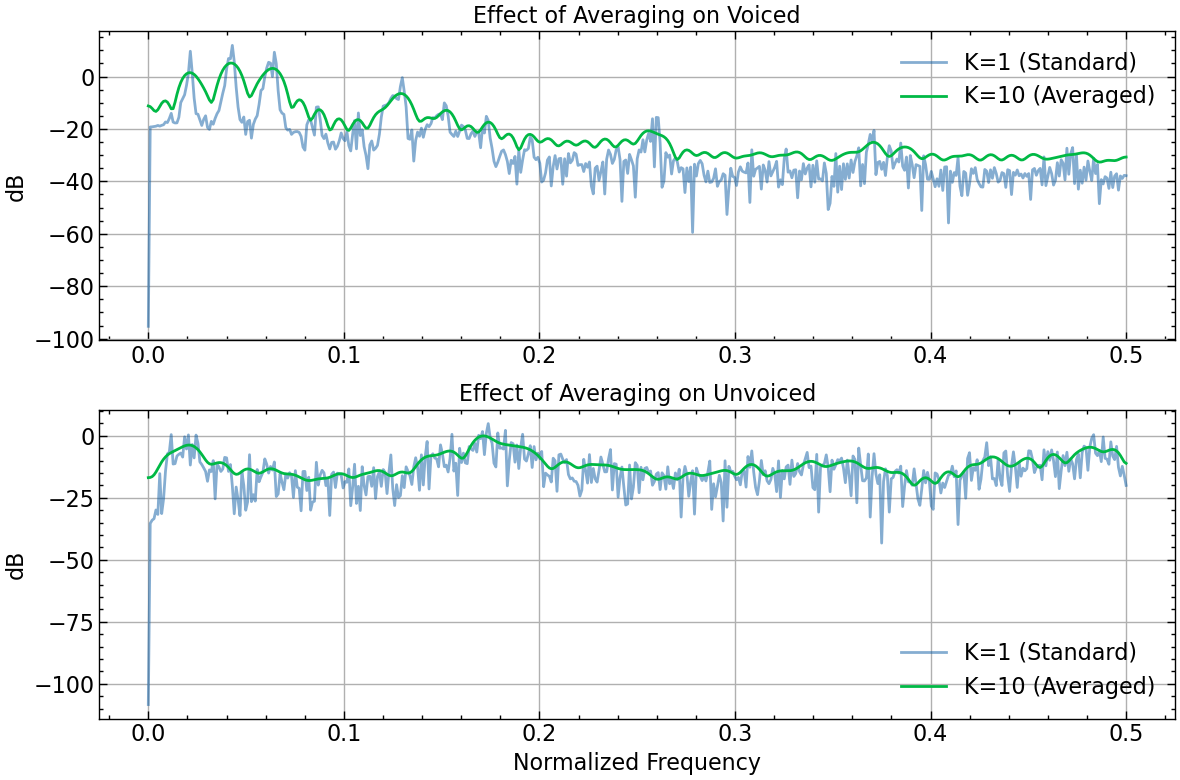

In [60]:
"""
sig, sr = sf.read('sound_files/voise_oo.flac')
x_voiced = sig[0:Nfft] # Take a small block

plt.plot(sig)
plt.title("Waveform of 'oo' sound")
plt.grid()
plt.show()

Cx_biased, lags_biased = biaisedCrossCorr(x_voiced, pmax)
Cx_unbiased, lags_unbiased = unbiaisedCrossCorr(x_voiced, pmax)

plt.figure(figsize=(12, 6))
plt.stem(lags_unbiased, Cx_unbiased, markerfmt='red', linefmt='red', label='Unbiased')
plt.stem(lags_biased, Cx_biased, label='Biased')
plt.title("Autocorrelation of Voise Signal")
plt.xlabel("Lag (p)")
plt.legend()
plt.grid()
plt.show()

sig2, sr2 = sf.read('sound_files/nonvoise_kss.flac')
x_voiced2 = sig2[0:Nfft]

Cx_biased2, lags_biased2 = biaisedCrossCorr(x_voiced2, pmax)
Cx_unbiased2, lags_unbiased2 = unbiaisedCrossCorr(x_voiced2, pmax)

plt.figure(figsize=(12, 6))
plt.stem(lags_unbiased2, Cx_unbiased2, markerfmt='red', linefmt='red',  label='Unbiased')
plt.stem(lags_biased2, Cx_biased2, label='Biased')
plt.title("Autocorrelation of Non Voise Signal")
plt.xlabel("Lag (p)")
plt.legend()
plt.grid()
plt.show()
-------------------------------------------------------------------------
"""
# --- Setup ---
N = 2000  # Increased sample count to allow splitting
bruit = np.random.randn(N)
ar1 = s.lfilter([1], [1, -0.9], bruit)
Nfft = 1024

# --- Compute ---
# Without averaging (High Variance)
sig, sr = sf.read('sound_files/voise_oo.flac')
x_voiced = sig[0:Nfft] # Take a small block
sig2, sr2 = sf.read('sound_files/nonvoise_kss.flac')
x_voiced2 = sig2[0:Nfft]
P_noise_1, f_1 = psdestimator_per_avg(x_voiced, Nfft, K=1)
P_ar_1, _      = psdestimator_per_avg(x_voiced2,   Nfft, K=1)

# With averaging (Lower Variance, Lower Resolution)
P_noise_10, f_10 = psdestimator_per_avg(x_voiced, Nfft, K=10)
P_ar_10, _       = psdestimator_per_avg(x_voiced2,   Nfft, K=10)

# --- Plot ---
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(f_1, 10*np.log10(P_noise_1), label='K=1 (Standard)', alpha=0.5)
plt.plot(f_10, 10*np.log10(P_noise_10), label='K=10 (Averaged)', linewidth=2)
plt.title("Effect of Averaging on Voiced")
plt.legend(); plt.grid(); plt.ylabel("dB")

plt.subplot(2, 1, 2)
plt.plot(f_1, 10*np.log10(P_ar_1), label='K=1 (Standard)', alpha=0.5)
plt.plot(f_10, 10*np.log10(P_ar_10), label='K=10 (Averaged)', linewidth=2)
plt.title("Effect of Averaging on Unvoiced")
plt.legend(); plt.grid(); plt.xlabel("Normalized Frequency"); plt.ylabel("dB")

plt.tight_layout()
plt.show()

$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 9 :** </span> Visualiser l'effet de différentes fenêtres sur un signal connu.

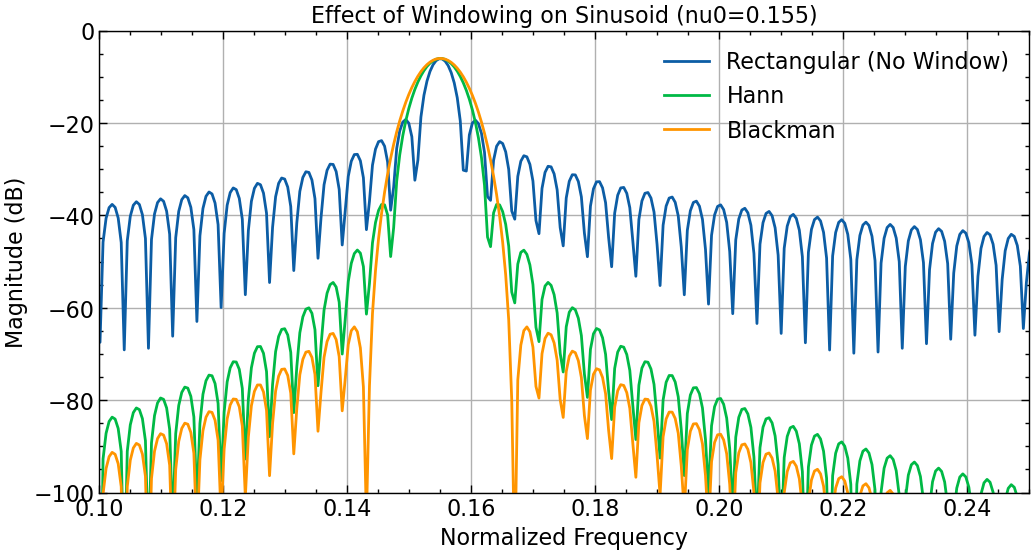

In [21]:
# --- Signal Parameters ---
N = 256
nu0 = 0.155 # Choose a frequency that is NOT an integer multiple of 1/N to force leakage
n = np.arange(N)
# Pure sinusoid
x = np.sin(2 * np.pi * nu0 * n)

# --- Define Windows ---
w_rect = np.ones(N)
w_hann = np.hanning(N)
w_hamm = np.hamming(N)
w_black = np.blackman(N)

# --- Compute PSDs with Windows ---
# We use a large Nfft (zero-padding) to clearly see the shape of the lobes
Nfft = 2048 

# Helper to compute windowed spectrum
def compute_windowed_spectrum(x, w, Nfft):
    # Apply window
    x_w = x * w
    # Compute FFT
    X_f = np.fft.fft(x_w, Nfft)
    # Compute Magnitude (dB)
    # Normalization: divide by sum of window to normalize amplitude
    spec = 20 * np.log10(np.abs(X_f) / np.sum(w) + 1e-12) 
    return spec

f_axis = np.fft.fftfreq(Nfft)
mask = f_axis >= 0
f_axis = f_axis[mask]

S_rect = compute_windowed_spectrum(x, w_rect, Nfft)[mask]
S_hann = compute_windowed_spectrum(x, w_hann, Nfft)[mask]
S_black = compute_windowed_spectrum(x, w_black, Nfft)[mask]

# --- Visualization ---
plt.figure(figsize=(12, 6))
plt.plot(f_axis, S_rect, label='Rectangular (No Window)')
plt.plot(f_axis, S_hann, label='Hann')
plt.plot(f_axis, S_black, label='Blackman')

plt.xlim(0.1, 0.25) # Zoom in on the peak
plt.ylim(-100, 0)
plt.title(f"Effect of Windowing on Sinusoid (nu0={nu0})")
plt.xlabel("Normalized Frequency")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid()
plt.show()

>1. Rectangular: Narrowest main peak (best resolution) but highest side lobes (~ -13dB). Bad for detecting weak signals hidden by strong ones.
>
>2. Hann/Hamming: Wider main peak (slightly worse resolution), but side lobes drop significantly.
>
>3. Blackman: Widest main peak (worst resolution), but extremely low side lobes (~ -58dB). Best for dynamic range.
>
>4. Normalization: To ensure the PSD magnitude is correct, we divide the squared modulus by the energy of the window U=∑∣w[n]∣^2 (for Power) or the sum of the window S=(∑w[n])^2 (for Amplitude).

In [22]:
def psd_windowed(x: np.ndarray, window_name='rect', Nfft=None):
    N = len(x)
    if Nfft is None: Nfft = N
    
    # Create window
    if window_name == 'hann':
        w = np.hanning(N)
    elif window_name == 'hamming':
        w = np.hamming(N)
    elif window_name == 'blackman':
        w = np.blackman(N)
    else:
        w = np.ones(N)
        
    # Apply window
    x_w = x * w
    
    # Calculate Energy Normalization Factor (to recover Variance)
    U = np.sum(w**2)
    
    # FFT
    X_f = np.fft.fft(x_w, Nfft)
    
    # PSD
    P = (np.abs(X_f)**2) / U
    
    # Freqs
    nu = np.fft.fftfreq(Nfft)
    mask = nu >= 0
    
    return P[mask], nu[mask]

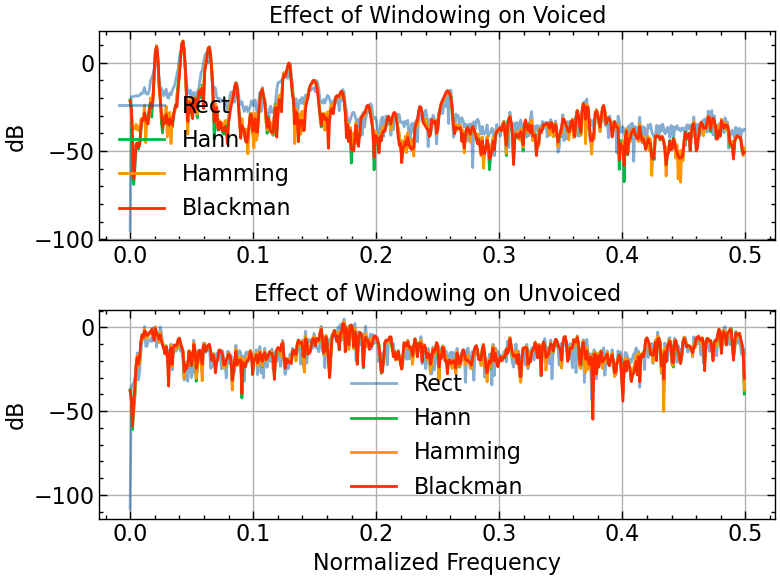

In [64]:
#Nfft = 1024

# --- Compute ---
# Without averaging (High Variance)
sig, sr = sf.read('sound_files/voise_oo.flac')
x_voiced = sig[0:Nfft] # Take a small block
sig2, sr2 = sf.read('sound_files/nonvoise_kss.flac')
x_voiced2 = sig2[0:Nfft]

psd_windowed(x_voiced)

plt.subplot(2, 1, 1)
plt.plot(psd_windowed(x_voiced)[1], 10*np.log10(psd_windowed(x_voiced)[0]), label='Rect', alpha=0.5)
plt.plot(psd_windowed(x_voiced,'hann')[1], 10*np.log10(psd_windowed(x_voiced,'hann')[0]), label='Hann', linewidth=2)
plt.plot(psd_windowed(x_voiced,'hamming')[1], 10*np.log10(psd_windowed(x_voiced,'hamming')[0]), label='Hamming', linewidth=2)
plt.plot(psd_windowed(x_voiced,'blackman')[1],10*np.log10(psd_windowed(x_voiced,'blackman')[0]), label='Blackman', linewidth=2)

plt.title("Effect of Windowing on Voiced")
plt.legend(); plt.grid(); plt.ylabel("dB")

plt.subplot(2, 1, 2)
plt.plot(psd_windowed(x_voiced2)[1], 10*np.log10(psd_windowed(x_voiced2)[0]), label='Rect', alpha=0.5)
plt.plot(psd_windowed(x_voiced2,'hann')[1], 10*np.log10(psd_windowed(x_voiced2,'hann')[0]), label='Hann', linewidth=2)
plt.plot(psd_windowed(x_voiced2,'hamming')[1], 10*np.log10(psd_windowed(x_voiced2,'hamming')[0]), label='Hamming', linewidth=2)
plt.plot(psd_windowed(x_voiced2,'blackman')[1], 10*np.log10(psd_windowed(x_voiced2,'blackman')[0]), label='Blackman', linewidth=2)
plt.title("Effect of Windowing on Unvoiced")
plt.legend(); plt.grid(); plt.xlabel("Normalized Frequency"); plt.ylabel("dB")

plt.tight_layout()
plt.show()

***

<a id="seance3"></a>
## Séance 3 : Prédiction linéaire

> $\quad$  
> **Objectifs de séance :** 
> - Mettre en oeuvre la prédiction linéaire afin d'estimer les paramètres d'un modèle source/filtre des sons voisés et non voisés constituant la parole.  
> $\quad$

La prédiction linéaire optimale permet de décorréler les échantillons du signal. Plus précisément, à un ordre $K$, l'erreur de prédiction $e(n,\omega)$ est décorrélée des $K$ derniers échantillons du signal ${X}(n,\omega)$. On espère qu'ainsi, pour des sons vocaux, l'erreur de prédiction puisse fournir une estimation de la *source d'excitation* et que les coefficients optimaux donnent un bon modèle de *filtre*.

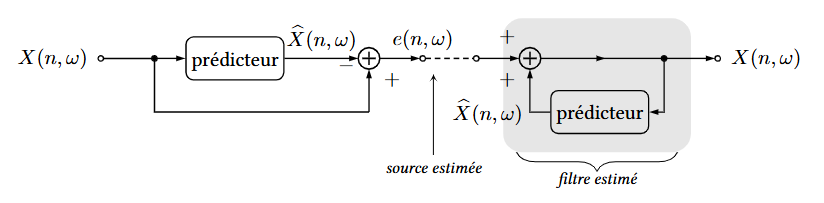

<a id="s3-yule-walker"></a>
### Résolution des équations de Yule-Walker

Ecrire la fonction résolvant le système d'équations de Yule-Walker et décrite de la manière suivante :

In [39]:
def yulewalkersolver(Cx: np.ndarray, K: int):
    """Solve the Yule-Walker equations for a given sequence of autocorrelation
    
    Inputs
    ----------
    Cx : np.ndarray
        Biased autocorrelation vector (lags 0 to pmax, where pmax >= K)
    K : int
        Order of the prediction
        
    Returns
    -------
    a : np.ndarray
        Vector of filter coefficients [a1, a2, ..., aK]
    sigma2 : float
        Prediction error variance (innovation power)
    """
    
    # Build Toeplitz Matrix Gamma
    # Uses lags 0 to K-1
    # toeplitz([c0, c1]) -> [[c0, c1], [c1, c0]]
    Gamma = sp.toeplitz(Cx[0:K])

    Gamma_inv = np.linalg.inv(Gamma)
    
    # Build vector gamma (lags 1 to K)
    gamma = Cx[1:K+1]
    
    # Solve Gamma * a = gamma
    a = Gamma_inv@gamma
    
    # Compute variance of prediction error
    # sigma^2 = R[0] + sum(a_k * R[k])
    sigma2 = Cx[0] + np.dot(a, gamma)
    
    return a, sigma2
    

**Conseil :** On pourra utiliser la fonction `sp.toeplitz` pour générer la matrice $\Gamma$ à partir du vecteur de termes de l'estimateur biaisé de l'autocorrélation $\hat{\gamma}_{X}$.

<a id="s3-process"></a>
### Réalisations de processus connus

$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 10 :** </span> Tester la fonction en utilisant directement les *coefficients d'autocorrélation théorique* de processus aléatoires connus (voir Cours ou TD).

--- Bruit Blanc (K=1) ---
Coefficient a estimé (devrait être proche de 0) : [-0.02369577]


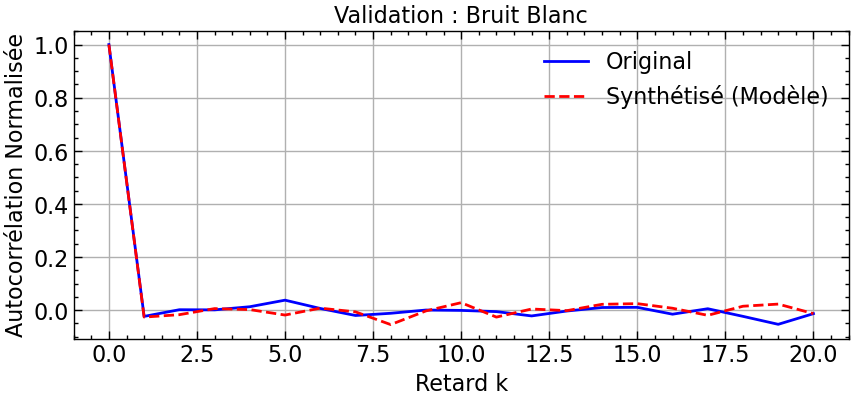


--- AR(1) (K=1) ---
Coefficient a estimé (Attendu ~0.9) : [-0.89486379]


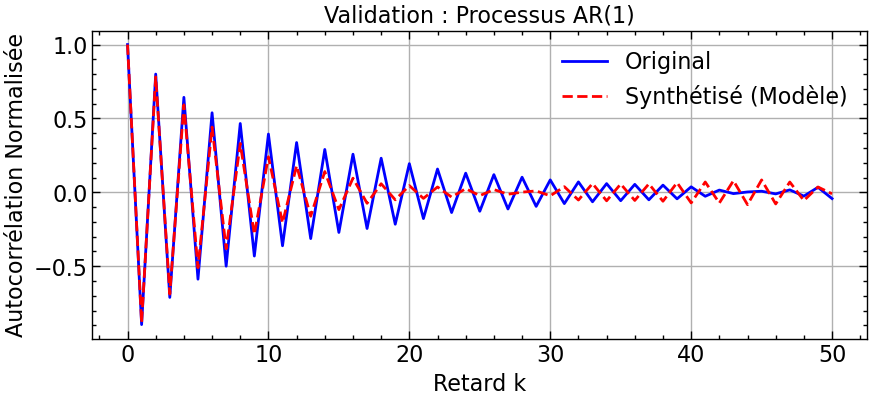


--- AR(1) (K=20) ---
Coefficient a estimé (Attendu ~0.9) : [-8.94910320e-01  2.25704525e-02  7.90018202e-02  3.16214156e-02
 -2.68925218e-02 -2.50280208e-02 -1.61050416e-02  3.16667498e-02
 -8.05554960e-04 -2.32037591e-02  2.04403932e-02  3.77096112e-02
  5.35638886e-03 -1.46204317e-02  5.39735586e-03  2.55085236e-02
  6.67581145e-03  9.47348903e-03 -2.48727645e-02 -3.63264248e-02]


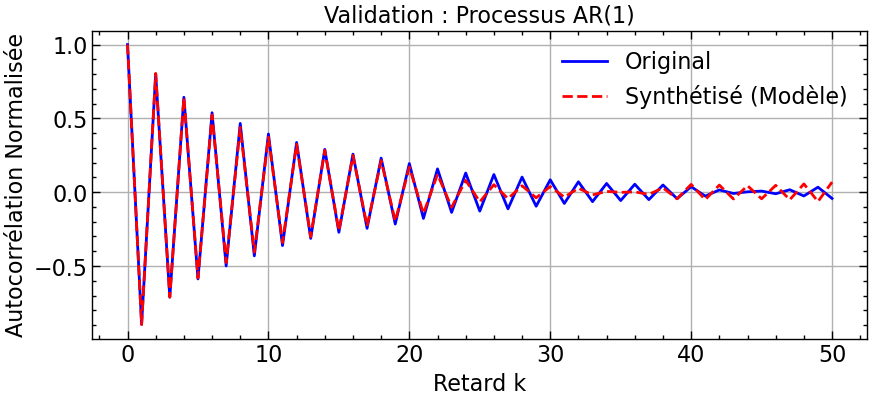


--- SPA (Sinusoïde) (K=2) ---
Coefficients a estimés : [ 1.90017675 -0.99806309]


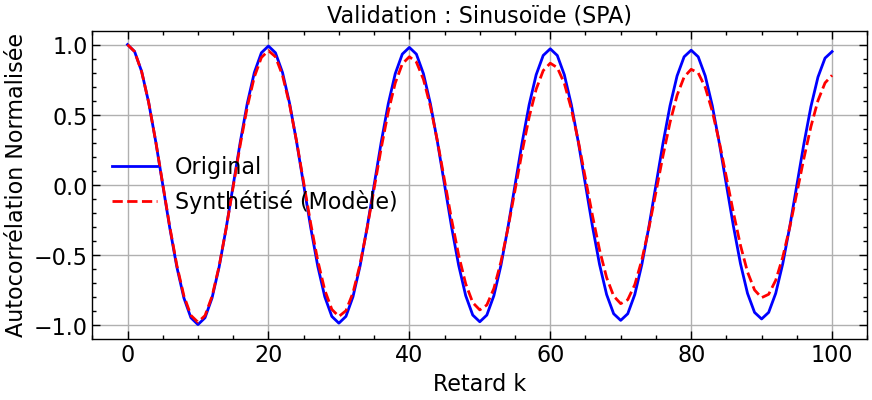


--- SPA (Sinusoïde) (K=20) ---
Coefficients a estimés : [ 1.62801179e+00 -5.54035234e-01 -1.51597254e-01 -4.14806245e-02
 -1.13500881e-02 -3.10565487e-03 -8.49781303e-04 -2.32520586e-04
 -6.36240320e-05 -1.74116249e-05 -4.77419871e-06 -1.34242327e-06
 -4.99308044e-07 -6.19040406e-07 -1.93235337e-06 -6.97185897e-06
 -2.54549927e-05 -9.30223932e-05 -3.39962630e-04  3.28892353e-04]


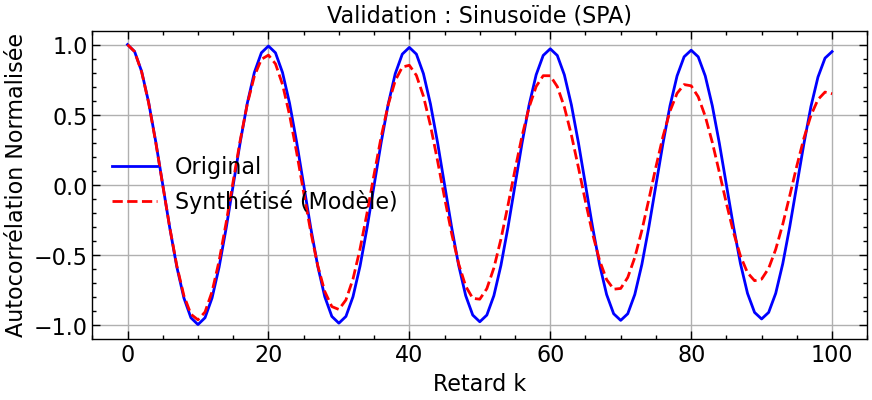

In [40]:
def synthetiser_signal(a_coeffs, variance, N_samples):
    ecart_type = np.sqrt(np.abs(variance))
    excitation = ecart_type * np.random.randn(N_samples)

    a_poly = np.concatenate(([1], -a_coeffs))
    signal_synth = s.lfilter([1], a_poly, excitation)

    return signal_synth

def comparer_autocorrelations(titre, x_orig, x_synth, pmax=50):
    Cx_orig, lags = biaisedCrossCorr(x_orig, pmax=pmax)
    Cx_synth, _ = biaisedCrossCorr(x_synth, pmax=pmax)
    
    Cx_orig_norm = Cx_orig / Cx_orig[0]
    Cx_synth_norm = Cx_synth / Cx_synth[0]
    
    plt.figure(figsize=(10, 4))
    plt.plot(lags, Cx_orig_norm, 'b-', linewidth=2, label='Original')
    plt.plot(lags, Cx_synth_norm, 'r--', linewidth=2, label='Synthétisé (Modèle)')
    plt.title(f"Validation : {titre}")
    plt.xlabel("Retard k")
    plt.ylabel("Autocorrélation Normalisée")
    plt.legend()
    plt.grid()
    plt.show()

# 1. White Noise
N = 2000
x_bruit = np.random.randn(N)

K1 = 1
Cx_bruit, _1 = biaisedCrossCorr(x_bruit, pmax=20)
a_est1, v_est1 = yulewalkersolver(Cx_bruit, K1)

x_bruit_synth1 = synthetiser_signal(a_est1, v_est1, N)

print(f"--- Bruit Blanc (K={K1}) ---")
print(f"Coefficient a estimé (devrait être proche de 0) : {a_est1}")
comparer_autocorrelations("Bruit Blanc", x_bruit, x_bruit_synth1, pmax=20)

# 2. PROCESSUS AR(1)
a_true = 0.9
x_ar1 = s.lfilter([1], [1, a_true], np.random.randn(N))

K=1
K2 = 20

Cx_ar1, _ = biaisedCrossCorr(x_ar1, pmax=20)
a_est, v_est = yulewalkersolver(Cx_ar1, K)

x_ar1_synth = synthetiser_signal(a_est, v_est, N)

print(f"\n--- AR(1) (K={K}) ---")
print(f"Coefficient a estimé (Attendu ~{a_true}) : {a_est}")
comparer_autocorrelations("Processus AR(1)", x_ar1, x_ar1_synth, pmax=50)

a_est2, v_est2 = yulewalkersolver(Cx_ar1, K2)

x_ar1_synth2 = synthetiser_signal(a_est2, v_est2, N)

print(f"\n--- AR(1) (K={K2}) ---")
print(f"Coefficient a estimé (Attendu ~{a_true}) : {a_est2}")
comparer_autocorrelations("Processus AR(1)", x_ar1, x_ar1_synth2, pmax=50)


# 3. SINUSOÏDE (SPA)
nu0 = 0.05
x_spa = np.sin(2 * np.pi * nu0 * np.arange(N) + np.random.uniform(0, 2*np.pi))

K = 2
Cx_spa, _ = biaisedCrossCorr(x_spa, pmax=20)
a_est, v_est = yulewalkersolver(Cx_spa, K)

x_spa_synth = synthetiser_signal(a_est, v_est, N)

print(f"\n--- SPA (Sinusoïde) (K={K}) ---")
print(f"Coefficients a estimés : {a_est}")
comparer_autocorrelations("Sinusoïde (SPA)", x_spa, x_spa_synth, pmax=100)

a_est2, v_est2 = yulewalkersolver(Cx_spa, K2)

x_spa_synth2 = synthetiser_signal(a_est2, v_est2, N)

print(f"\n--- SPA (Sinusoïde) (K={K2}) ---")
print(f"Coefficients a estimés : {a_est2}")
comparer_autocorrelations("Sinusoïde (SPA)", x_spa, x_spa_synth2, pmax=100)

> For the white noise, the coefficient is close to zero, the signal is not predictable
>
> For the AR(1), the simulation gives a value close to the real one. For K >> 1, the first value is usefull, the other one are close to zero. When K is overestimated, the signal is not impact.
>
>For the SPA, an overestimated K gives less accurate values and the signal is less close to the original.

Liste non exhaustive de questions que l'on peut se poser :

- Que faire dans la fonction `yulewalkersolver` si le vecteur de termes de l'estimateur $\hat{\gamma}_{X}$ fournit contient moins de $K + 1$ éléments ?
- Avec l’autocorrélation de quel processus connu peut-on tester la fonction à l’ordre $K = 1$ ? Quels coefficients optimaux attend-t-on ?
- Avec l’autocorrélation de quel processus connu peut-on tester la fonction à l’ordre $K = 2$ ? Quels coefficients optimaux attend-t-on ?
- Comment tester le bon fonctionnement de la fonction à un ordre K supérieur ?
- Que se passe-t-il avec un $\operatorname{AR}(1)$ et $K > 1$ ?
- Que se passe-t-il avec une sinusoïde à phase aléatoire et $K > 2$ ?
- Comment évolue la variance d’erreur de prédiction en fonction de l’ordre $K$ ? Pour un processus donné, quel ordre $K$ choisir ?
- Comment le signal prédit se compare-t-il à une réalisation donnée du signal original ?
- Quelle est l’allure de l’autocorrélation de l’erreur de prédiction en fonction du décalage $p$ ? Avec quel processus peut-on modéliser cette erreur ?
- Comment l’autocorrélation d’erreur de prédiction se compare-t-elle à l’autocorrélation du signal ?
- En modélisant le signal par un processus $\operatorname{AR}(K)$ défini par les paramètres fournis par la prédiction linéaire, quelle est l’allure de la DSP estimée ? Dans quelle mesure concorde-t-elle avec la DSP théorique ?

<a id="s3-v-nv"></a>
### Sons voisés et non voisés

$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 11 :** </span> Reprendre l'étude précédente avec les sons voisés et non voisés fournis.

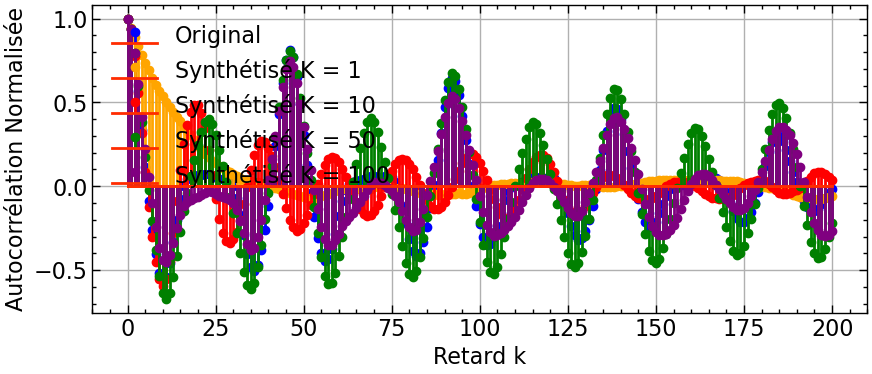

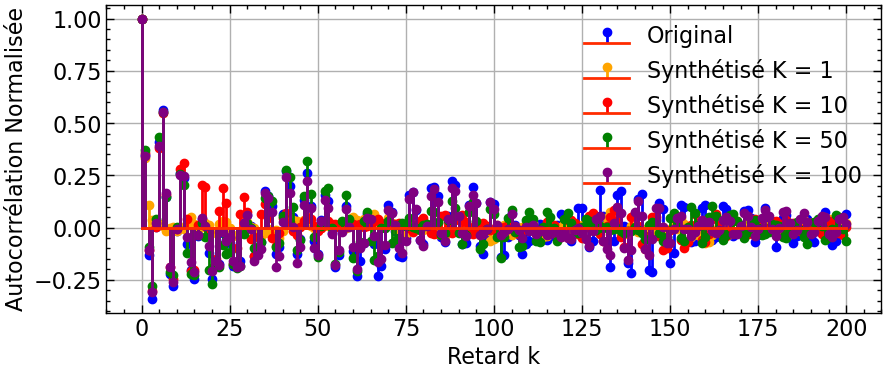

In [54]:
sig, sr = sf.read('sound_files/voise_oo.flac')
x_voiced = sig[0:256]

Cx_voiced, lags_voiced = biaisedCrossCorr(x_voiced, pmax=200)

K_list = [1, 10, 50, 100]
d_clr ={1 : "orange", 10:"r",50:"g",100:"purple"}

plt.figure(figsize=(10, 4))
Cx_voiced, lags = biaisedCrossCorr(x_voiced, pmax=200)
Cx_voiced_norm = Cx_voiced / Cx_voiced[0]
plt.stem(lags, Cx_voiced_norm, 'b-', label='Original')

for K in K_list:
    a_est, v_est = yulewalkersolver(Cx_voiced, K)
    x_synth = synthetiser_signal(a_est, v_est, N)
    
    Cx_synth, _ = biaisedCrossCorr(x_synth, pmax=200)
    Cx_synth_norm = Cx_synth / Cx_synth[0]
    
    plt.stem(lags, Cx_synth_norm,linefmt=d_clr[K], markerfmt=d_clr[K], label=f'Synthétisé K = {K}')

plt.xlabel("Retard k")
plt.ylabel("Autocorrélation Normalisée")
plt.legend()
plt.grid()
plt.show()

sig, sr = sf.read('sound_files/nonvoise_kss.flac')
x_nonvoiced = sig[0:256]

plt.figure(figsize=(10, 4))
Cx_nonvoiced, lags = biaisedCrossCorr(x_nonvoiced, pmax=200)
Cx_nonvoiced_norm = Cx_nonvoiced / Cx_nonvoiced[0]
plt.stem(lags, Cx_nonvoiced_norm, 'b-', label='Original')

for K in K_list:
    a_est, v_est = yulewalkersolver(Cx_nonvoiced, K)
    x_synth = synthetiser_signal(a_est, v_est, N)
    
    Cx_synth, _ = biaisedCrossCorr(x_synth, pmax=200)
    Cx_synth_norm = Cx_synth / Cx_synth[0]
    
    plt.stem(lags, Cx_synth_norm,linefmt=d_clr[K], markerfmt=d_clr[K], label=f'Synthétisé K = {K}')

plt.xlabel("Retard k")
plt.ylabel("Autocorrélation Normalisée")
plt.legend()
plt.grid()
plt.show()


> For real sound, K have to be at least 10, at most 50. Between 50 and max there is few differences.

Liste non exhaustive de questions que l’on peut se poser :
- À quel ordre $K$ semble-t-il raisonnable de limiter la prédiction linéaire pour les sons voisés ? Pour les sons non voisés ?
- Selon le caractère voisé du signal, quelle est l’allure de l’autocorrélation de l’erreur de prédiction en fonction du décalage $p$ ? Avec quel processus peut-on modéliser ces erreurs ?
- Comment les estimations spectrales paramétriques se comparent-elles à celles non paramétriques réalisées lors de la séance précédente ?

Finalement, disposant de modèles de filtres et de processus d’excitation, **nous sommes en mesure de générer des sons voisés et non voisés synthétiques**.   
À partir des caractéristiques extraites des sons fournis, générer des sons synthétiques sur des durées de plusieurs secondes et vérifier la qualité sonore de cette synthèse.

***

<a id="seance4"></a>
## Séance 4 : Codage (compression), décodage et effets sur la parole

> $\quad$  
> **Objectifs de séance :** 
> - Mettre en oeuvre le codage/décodage du signal de parole par prédiciton linéaire en traitant le signal par tronçon.
> - Comparaison des signaux synthétiques et réels avec les outils de traitement du signal (autocorrélation, spectre) et à l'oreille.
> - Application d'effet sur la voix par modification des caractéristiques analysées sur les tronçons.  
> $\quad$

Il s’agit maintenant de rassembler des différents outils développés lors des séances précédentes de manière à analyser et synthétiser des signaux vocaux de longue durée.   
Si vous avez rencontré des diffcultés avec l’implémentation de certaines fonctions, il est possible, dans une certaine mesure de s’en affranchir.   
Le tableau suivant montre les équivalences avec des fonctions de base.

| Estimateur        |     Code réalisé          | Fonctions toutes faites de référence   |
|:-----------------:|:-------------------------:|:--------------------------------------:|
| Autocorrélation   | [un]biasedcrosscorr       |                      `numpy.correlate` |
|     Spectre       |        psdestimator       |                   `scipy.signal.welch` |
|     Filtre de prédiction       |        yulewalkersolver       |                   `librosa.lpc` |
| Pitch             |  isvoiced                 |  `librosa.pyin`|

<a id="s4-analyse"></a>
### Analyse d'un tronçon

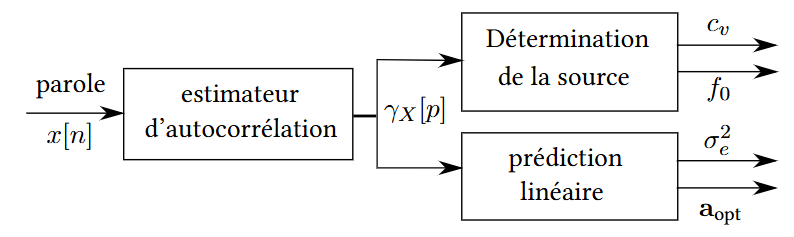

Après avoir écrit un fonction permettant d'obtenir le pitch d'un signal voisé, écrire la fonction permettant d'analyser un tronçon de signal de $256$ échantillons, décrite de la manière suivante :

In [26]:
import numpy as np

def pitchdetector(
    X: np.ndarray, Fe: float = 10_000, Fmin: float = 100, Fmax: float = 1000):
    """Determine the pitch of a signal based on its cross-correlation

    Inputs
    ----------
    X : np.ndarray
        Vector of signal samples
    Fe : float, optional
        Sampling rate, by default 10_000
    Fmin : float, optional
        Minimal pitch, by default 100
    Fmax : float, optional
        Maximal pitch, by default 400

    Returns
    -------
    pitch : float
        The pitch value in normalized frequency if the sound is voiced, -1 otherwise
    """

    # biased cross-correlation of the signal
    # determination of pmax
    pmax = int(Fe / Fmin)
    if pmax >= len(X): pmax = len(X) - 1
    
    Cx, lags = biaisedCrossCorr(X, pmax=pmax)
    
    # Normalization
    if Cx[0] == 0: return -1 # if cross-corr is null
    Cx_norm = Cx / Cx[0]

    # search of the peak between Fmin and Fmax
    lag_min = int(Fe / Fmax)
    lag_max = int(Fe / Fmin)

    if lag_max > len(Cx_norm): lag_max = len(Cx_norm)

    search_zone = Cx_norm[lag_min:lag_max]

    if len(search_zone) == 0: return -1 # if the search zone is null

    idx_max_local = np.argmax(search_zone)

    lag_pitch = lag_min + idx_max_local

    bool = isvoiced(x)

    if bool : return 1.0 / lag_pitch
 
    return -1

In [46]:
def blockanalysis(X: np.ndarray, M: int = 10, Fe: float = 10_000):
    """Analyses the samples of a supposedly stationnary process and fits the parameters of a model source/filter

    Inputs
    ----------
    X : np.ndarray
        Vector of samples of the current block of signal
    M : int, optional
        Filter order, by default 10
    Fe : float, optional
        Sampling frequency, by default 10_000

    Returns
    -------
    pitch : float
        The pitch value in normalized frequency if the sound is voiced, -1 overwise
    sigma2 : float
        The variance of excitation
    Aopt : np.ndarray
        Vector of filter coefficients (optimal prediction of order M)
    """

    # biased cross-corr of the signal
    # at least M lag for the filter order
    Cx, lags = biaisedCrossCorr(X, pmax=M)
    
    # Yule-Walker : Estimation of the Filter and variance of excitation
    Aopt, sigma2 = yulewalkersolver(Cx, M)
    
    # detection of the pitch
    pitch = pitchdetector(X, Fe=Fe)
    
    return pitch, sigma2, Aopt

<a id="s4-synthese"></a>
### Synthèse d'un tronçon

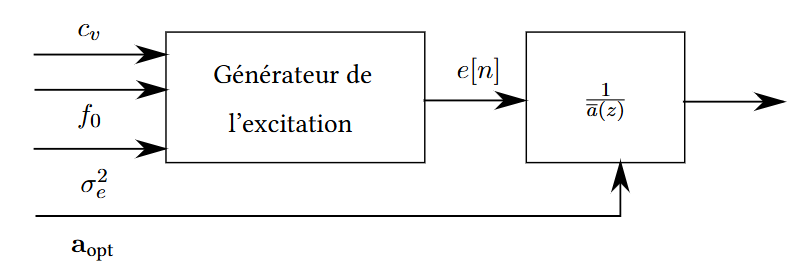

Ecrire la fonction permettant de synthétiser un tronçon de signal, décrite de la manière suivante :

In [47]:
def blocksynthesis(pitch: float, sigma2: float, Aopt: np.ndarray, N: int):
    """Analyses the samples of a supposedly stationnary process and fits the parameters of a model source/filter

    Parameters
    ----------
    pitch : float
        The pitch value in normalized frequency if the sound is voiced, -1 overwise
    sigma2 : float
        The variance of excitation
    Aopt : np.ndarray
        Vector of filter coefficients (optimal prediction of order M)
    N : int
        Number of samples to be synthetized

    Returns
    -------
    Y : np.ndarray
        Synthetized block
    """

    # Generation of the excitation
    gain = np.sqrt(np.abs(sigma2)) # the power of the excitation have to be sigma2

    if (pitch > 0): #signal is voiced
        # Generation of a signal with a frq f0 and a total power sigma2
        T0 = int(1.0 / pitch)
        excitation = np.zeros(N)
        excitation[::T0] = 1.0

        excitation *= (gain * np.sqrt(T0))
    else: #signal is non voiced
        excitation = gain * np.random.randn(N)

    # filter 1 / A(z)
    a_poly = [1] + [-aopt for aopt in Aopt]
    Y = s.lfilter([1], a_poly, excitation)
    
    return Y
       

$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 12 :** </span> Tester les fonctions précédentes pour un signal connu en comparant la reconstruction avec le signal de départ (en terme d'autocorrélation ou de DSP)

1. Signal Original (Sinus Pur 440Hz)



2. Paramètres extraits :
   - Pitch détecté : 0.0435 (Fréquence norm.) -> 434.8 Hz
   - Coefficients a: [ 1.83407959 -0.91316995]

3. Signal Synthétisé (Modèle LPC)
   Note : Le son sera plus 'métallique' ou 'buzzy' (excitation impulsionnelle).


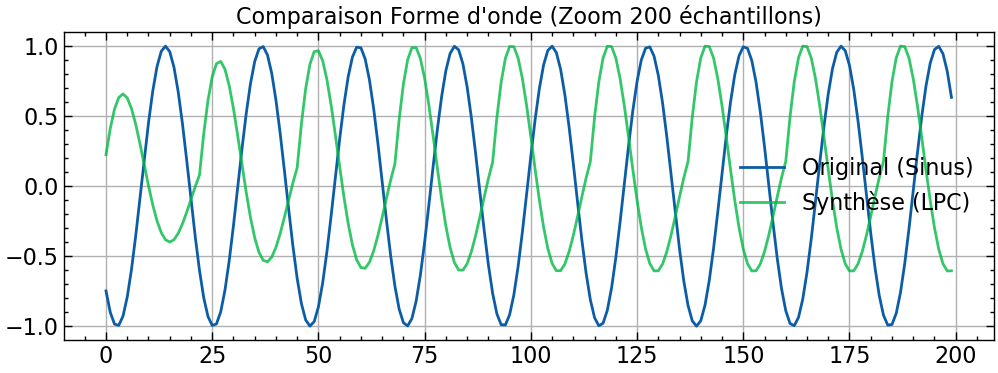

In [48]:
# --- Fonction utilitaire pour l'écoute (Normalisation) ---
def ecouter_signal(signal, Fe=10000):
    # Centrer et Normaliser pour éviter la saturation
    sig_norm = signal - np.mean(signal)
    if np.max(np.abs(sig_norm)) > 0:
        sig_norm = sig_norm / np.max(np.abs(sig_norm))
    return ipd.Audio(sig_norm, rate=Fe)

# 1. CRÉATION DU SIGNAL (SPA)
Fe = 10000
f0 = 440       # La note La (440 Hz)
N_analyse = 256  # Taille du tronçon pour l'analyse
N_ecoute = 10000 # 1 seconde pour l'écoute

# Génération du sinus original (court pour l'analyse)
n = np.arange(N_analyse)
x_spa = np.sin(2 * np.pi * f0/Fe * n + np.random.uniform(0, 2*np.pi))

print("1. Signal Original (Sinus Pur 440Hz)")
# Pour l'écoute de l'original, on en génère un long
x_spa_long = np.sin(2 * np.pi * f0/Fe * np.arange(N_ecoute))
display(ecouter_signal(x_spa_long, Fe))


# 2. ANALYSE (Codage)
# On utilise K=2 car c'est suffisant pour un sinus (K=10 marche aussi)
K = 2 
pitch, sigma2, a_opt = blockanalysis(x_spa, M=K, Fe=Fe)

print(f"\n2. Paramètres extraits :")
print(f"   - Pitch détecté : {pitch:.4f} (Fréquence norm.) -> {pitch*Fe:.1f} Hz")
print(f"   - Coefficients a: {a_opt}")


# ==========================================
# 3. SYNTHÈSE (Décodage)
# ==========================================
# On demande à la synthèse de générer 1 seconde (N_ecoute)
x_synth = blocksynthesis(pitch, sigma2, a_opt, N_ecoute)

print("\n3. Signal Synthétisé (Modèle LPC)")
print("   Note : Le son sera plus 'métallique' ou 'buzzy' (excitation impulsionnelle).")
display(ecouter_signal(x_synth, Fe))


# ==========================================
# 4. COMPARAISON VISUELLE (Zoom)
# ==========================================
plt.figure(figsize=(12, 4))
# On zoome sur 20ms pour voir la forme d'onde
zoom = 200 
plt.plot(x_spa[:zoom], label='Original (Sinus)')
# On normalise la synthèse pour comparer la forme (le volume dépend de sigma2)
plt.plot(x_synth[:zoom] / np.max(np.abs(x_synth[:zoom])), label='Synthèse (LPC)', alpha=0.8)
plt.title(f"Comparaison Forme d'onde (Zoom {zoom} échantillons)")
plt.legend()
plt.grid()
plt.show()

> On a augmenté Fmax dans pitch detector

<a id="s4-tns-effets"></a>
### Traitement d'un signal et effets

Commencez par écrire un script chargeant un signal sonore, l'analysant par tronçons puis synthétisant de nouveaux tronçons à partir des caractéristiques extraites. 

$\color{blue}\diamond$ <span style="color:blue"> **Checkpoint 13 :** </span> Après avoir découpé le signal en tronçons, réaliser la sythèse de l'ensemble des tronçons et les assembler. Que peut-on dire de la qualité du signal produit ? 

**Conseil :** Si les tronçons sont contigus sans recouvrement, les variations de puissances rapides en passant d'un tronçon à l'autre perturbent la qualité d'écoute. Pour pallier ce problème, on peut utiliser des tronçons pondérés par une fenêtre de Hann avec un recouvrement de 50%

<b> Effets que l'on peut envisager :</b>  
- Changement de tonalité sans changement de durée
- Passage à une voix chuchotée (bruit blanc pour l'excitation)
- Voix robotique (impulsion périodique pour l'excitation avec un fondamental fixe, indépendamment du signal analysé)
- Remplacement de l'excitation par une piste instrumentale